# Comprehensive Phishing Detection Analysis - Multi-Dataset Evaluation

Analisis lengkap perbandingan 4 model (Baseline, NMI, NMI+Filter, MI+Filter) untuk 3 dataset menggunakan feature selection dengan Top-N: 3, 5, 7, 10, 15, 20

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from urllib.parse import urlparse
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import entropy
from sklearn.preprocessing import KBinsDiscretizer
import warnings
warnings.filterwarnings('ignore')

try:
    import tldextract
    print("tldextract loaded")
except ImportError:
    import subprocess
    import sys
    print("Installing tldextract...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tldextract", "-q"])
    import tldextract
    print("tldextract installed")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All libraries loaded successfully")
print("=" * 80)

tldextract loaded
All libraries loaded successfully


## 1. Data Loading - Multi-Dataset Support

In [4]:
dataset_paths = [
    '../Dataset/Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14.csv',
    '../Dataset/Dataset_Crawling_Shuffle_2026-01-14_15-36-26.csv',
    '../Dataset/Dataset_Gabung_Merged_14780_2026-01-17_16-26-33.csv'
]

datasets = {}

print("=" * 80)
print("LOADING 3 DATASETS")
print("=" * 80)

for idx, path in enumerate(dataset_paths, 1):
    if os.path.exists(path):
        df = pd.read_csv(path)
        dataset_name = os.path.basename(path).replace('.csv', '')
        datasets[dataset_name] = df
        
        print(f"\nDataset {idx}: {dataset_name}")
        print(f"  Total URLs: {len(df):,}")
        print(f"  Columns: {df.columns.tolist()}")
        print(f"  Phishing: {(df['LABEL']=='phishing').sum():,}")
        print(f"  Legitimate: {(df['LABEL']=='legitimate').sum():,}")
    else:
        print(f"\nWarning: Dataset {idx} not found at {path}")
        print("  Please update path or place dataset in correct location")

print("\n" + "=" * 80)
print(f"Datasets loaded: {len(datasets)}")
print("=" * 80)

LOADING 3 DATASETS

Dataset 1: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14
  Total URLs: 5,930
  Columns: ['URL', 'LABEL']
  Phishing: 2,721
  Legitimate: 3,209

Dataset 2: Dataset_Crawling_Shuffle_2026-01-14_15-36-26
  Total URLs: 8,865
  Columns: ['URL', 'LABEL']
  Phishing: 4,399
  Legitimate: 4,466

Dataset 3: Dataset_Gabung_Merged_14780_2026-01-17_16-26-33
  Total URLs: 14,780
  Columns: ['URL', 'LABEL']
  Phishing: 7,120
  Legitimate: 7,660

Datasets loaded: 3


## 1.5 Data Visualization - Dataset Analysis


Generating visualizations for: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14


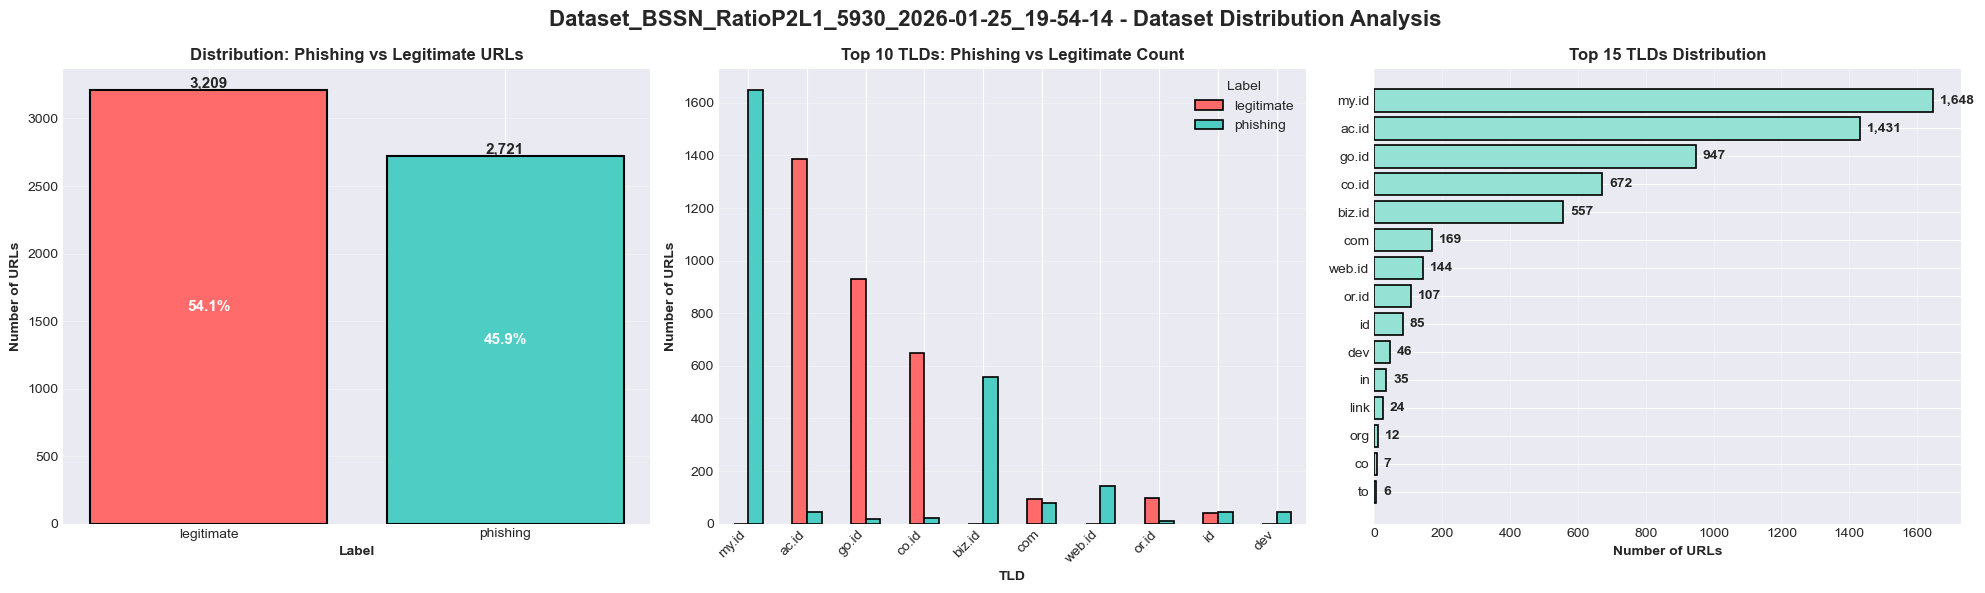


Dataset Statistics:
  Total URLs: 5,930
  Phishing URLs: 2,721 (45.89%)
  Legitimate URLs: 3,209 (54.11%)

TLD Statistics:
  Total Unique TLDs: 34
  Top 5 TLDs:
    my.id: 1,648 (27.79%)
    ac.id: 1,431 (24.13%)
    go.id: 947 (15.97%)
    co.id: 672 (11.33%)
    biz.id: 557 (9.39%)

Generating visualizations for: Dataset_Crawling_Shuffle_2026-01-14_15-36-26


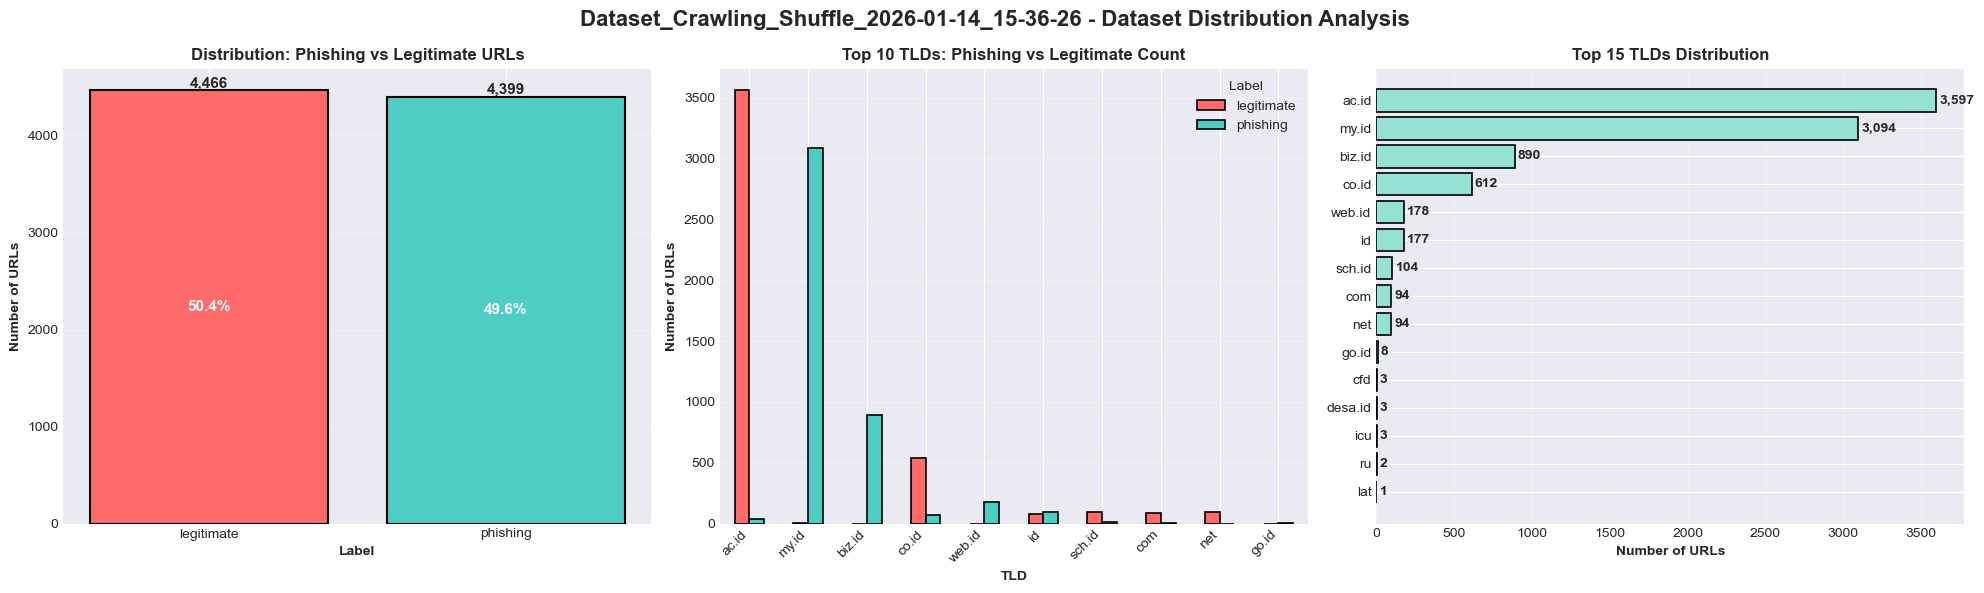


Dataset Statistics:
  Total URLs: 8,865
  Phishing URLs: 4,399 (49.62%)
  Legitimate URLs: 4,466 (50.38%)

TLD Statistics:
  Total Unique TLDs: 20
  Top 5 TLDs:
    ac.id: 3,597 (40.58%)
    my.id: 3,094 (34.90%)
    biz.id: 890 (10.04%)
    co.id: 612 (6.90%)
    web.id: 178 (2.01%)

Generating visualizations for: Dataset_Gabung_Merged_14780_2026-01-17_16-26-33


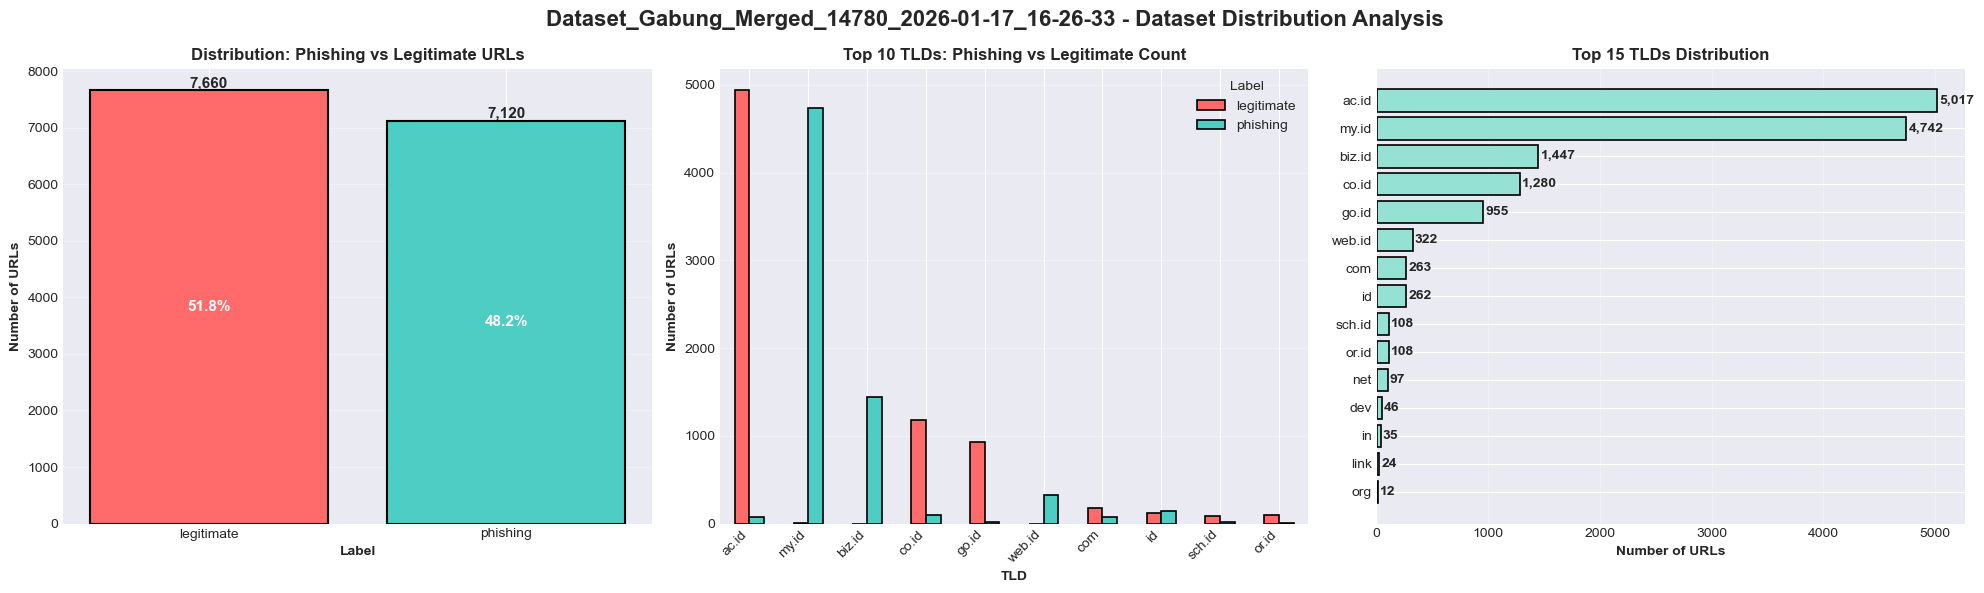


Dataset Statistics:
  Total URLs: 14,780
  Phishing URLs: 7,120 (48.17%)
  Legitimate URLs: 7,660 (51.83%)

TLD Statistics:
  Total Unique TLDs: 40
  Top 5 TLDs:
    ac.id: 5,017 (33.94%)
    my.id: 4,742 (32.08%)
    biz.id: 1,447 (9.79%)
    co.id: 1,280 (8.66%)
    go.id: 955 (6.46%)

Dataset visualization complete!


In [5]:
def visualize_dataset_analysis(datasets):
    """
    Create visualizations for each dataset:
    1. Distribution of Phishing vs Legitimate URLs
    2. Phishing & Legitimate URLs by TLD
    3. Distribution of TLDs
    """
    
    for dataset_name, df in datasets.items():
        print(f"\nGenerating visualizations for: {dataset_name}")
        print("=" * 100)
        
        # Remove protocol if exists
        df_clean = df.copy()
        
        def remove_protocol(url):
            if url.startswith('https://'):
                return url[8:]
            elif url.startswith('http://'):
                return url[7:]
            return url
        
        df_clean['URL'] = df_clean['URL'].apply(remove_protocol)
        
        # Extract TLD
        tld_list = []
        for url in df_clean['URL']:
            extracted = tldextract.extract(url)
            tld = extracted.suffix if extracted.suffix else 'Unknown'
            tld_list.append(tld)
        
        df_clean['TLD'] = tld_list
        
        # Create figure with 3 subplots
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f'{dataset_name} - Dataset Distribution Analysis', fontsize=16, fontweight='bold')
        
        # ----- SUBPLOT 1: Phishing vs Legitimate Distribution -----
        label_counts = df_clean['LABEL'].value_counts()
        colors_dist = ['#FF6B6B', '#4ECDC4']
        
        ax1 = axes[0]
        bars1 = ax1.bar(label_counts.index, label_counts.values, color=colors_dist, edgecolor='black', linewidth=1.5)
        ax1.set_title('Distribution: Phishing vs Legitimate URLs', fontweight='bold', fontsize=12)
        ax1.set_ylabel('Number of URLs', fontweight='bold')
        ax1.set_xlabel('Label', fontweight='bold')
        ax1.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontweight='bold', fontsize=11)
        
        # Add percentage labels
        total_urls = len(df_clean)
        for i, (label, count) in enumerate(zip(label_counts.index, label_counts.values)):
            pct = (count / total_urls) * 100
            ax1.text(i, count/2, f'{pct:.1f}%', ha='center', va='center', 
                    fontweight='bold', fontsize=11, color='white')
        
        # ----- SUBPLOT 2: Phishing & Legitimate by Top TLDs -----
        ax2 = axes[1]
        
        # Get top 10 TLDs
        top_tlds = df_clean['TLD'].value_counts().head(10).index
        df_top_tlds = df_clean[df_clean['TLD'].isin(top_tlds)]
        
        # Create pivot table for stacked bar chart
        tld_label_counts = pd.crosstab(df_top_tlds['TLD'], df_top_tlds['LABEL'])
        
        # Sort by TLD appearance
        tld_label_counts = tld_label_counts.loc[top_tlds]
        
        # Create stacked bar chart
        tld_label_counts.plot(kind='bar', ax=ax2, 
                            color=['#FF6B6B', '#4ECDC4'],
                            edgecolor='black', linewidth=1.2)
        
        ax2.set_title('Top 10 TLDs: Phishing vs Legitimate Count', fontweight='bold', fontsize=12)
        ax2.set_ylabel('Number of URLs', fontweight='bold')
        ax2.set_xlabel('TLD', fontweight='bold')
        ax2.legend(title='Label', loc='upper right', framealpha=0.9)
        ax2.grid(axis='y', alpha=0.3)
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # ----- SUBPLOT 3: Distribution of All TLDs -----
        ax3 = axes[2]
        
        tld_counts = df_clean['TLD'].value_counts()
        
        # Show top 15 TLDs
        top_15_tlds = tld_counts.head(15)
        
        bars3 = ax3.barh(range(len(top_15_tlds)), top_15_tlds.values, color='#95E1D3', edgecolor='black', linewidth=1.2)
        ax3.set_yticks(range(len(top_15_tlds)))
        ax3.set_yticklabels(top_15_tlds.index)
        ax3.set_title('Top 15 TLDs Distribution', fontweight='bold', fontsize=12)
        ax3.set_xlabel('Number of URLs', fontweight='bold')
        ax3.invert_yaxis()
        ax3.grid(axis='x', alpha=0.3)
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars3, top_15_tlds.values)):
            ax3.text(value + 20, i, f'{int(value):,}', va='center', fontweight='bold', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print(f"\nDataset Statistics:")
        print(f"  Total URLs: {len(df_clean):,}")
        print(f"  Phishing URLs: {(df_clean['LABEL']=='phishing').sum():,} ({(df_clean['LABEL']=='phishing').sum()/len(df_clean)*100:.2f}%)")
        print(f"  Legitimate URLs: {(df_clean['LABEL']=='legitimate').sum():,} ({(df_clean['LABEL']=='legitimate').sum()/len(df_clean)*100:.2f}%)")
        print(f"\nTLD Statistics:")
        print(f"  Total Unique TLDs: {df_clean['TLD'].nunique()}")
        print(f"  Top 5 TLDs:")
        for tld, count in tld_counts.head(5).items():
            pct = (count / len(df_clean)) * 100
            print(f"    {tld}: {count:,} ({pct:.2f}%)")

# Visualize all datasets
visualize_dataset_analysis(datasets)
print("\n" + "=" * 80)
print("Dataset visualization complete!")
print("=" * 80)

## 2. Configuration and Feature Extraction

In [6]:
ENTROPY_THRESHOLD = 3.5
INDONESIAN_WHITELIST_TLD = ['go.id', 'ac.id', 'sch.id', 'mil.id', 'desa.id']
TOP_N_VALUES = [3, 5, 7, 10, 15, 20]

def extract_features(url):
    """Extract features from URL - 52+ features matching baseline"""
    features = {}
    
    def calculate_entropy(text):
        if not text:
            return 0
        from collections import Counter
        import math
        char_freq = Counter(text)
        text_len = len(text)
        entropy = 0
        for count in char_freq.values():
            probability = count / text_len
            entropy -= probability * math.log2(probability)
        return entropy
    
    # Extract TLD, domain, subdomain using tldextract
    extracted = tldextract.extract(url)
    subdomain = extracted.subdomain
    domain_name = extracted.domain
    tld = extracted.suffix
    
    # Build full domain
    if subdomain and domain_name and tld:
        full_domain = f"{subdomain}.{domain_name}.{tld}"
    elif domain_name and tld:
        full_domain = f"{domain_name}.{tld}"
    else:
        full_domain = url.split('/')[0]
    
    # Parse URL for path and query
    url_with_protocol = 'http://' + url
    parsed = urlparse(url_with_protocol)
    path = parsed.path
    query = parsed.query
    
    # Basic features
    features['TLD'] = tld if tld else ''
    features['Subdomain'] = subdomain if subdomain else ''
    features['Domain'] = full_domain
    features['Entropy'] = calculate_entropy(url)
    
    # URL features
    features['UrlLength'] = len(url)
    features['DotCountURL'] = url.count('.')
    features['SlashCountURL'] = url.count('/')
    features['HyphenCountURL'] = url.count('-')
    features['QuestionmarkCountURL'] = url.count('?')
    features['EqualCountURL'] = url.count('=')
    features['AndCountURL'] = url.count('&')
    features['DollarCountURL'] = url.count('$')
    features['PercentCountURL'] = url.count('%')
    features['HashtagCountURL'] = url.count('#')
    features['AsteriskCountURL'] = url.count('*')
    features['PlusCountURL'] = url.count('+')
    features['CommaCountURL'] = url.count(',')
    
    # Domain features
    features['DomainLength'] = len(full_domain)
    features['DotCountDomain'] = full_domain.count('.')
    features['SlashCountDomain'] = full_domain.count('/')
    features['HyphenCountDomain'] = full_domain.count('-')
    features['QuestionmarkCountDomain'] = full_domain.count('?')
    features['EqualCountDomain'] = full_domain.count('=')
    features['AndCountDomain'] = full_domain.count('&')
    features['DollarCountDomain'] = full_domain.count('$')
    features['PercentCountDomain'] = full_domain.count('%')
    features['HashtagCountDomain'] = full_domain.count('#')
    features['PlusCountDomain'] = full_domain.count('+')
    features['CommaCountDomain'] = full_domain.count(',')
    
    # Path features
    features['PathLength'] = len(path)
    features['DotCountPath'] = path.count('.')
    features['SlashCountPath'] = path.count('/')
    features['HyphenCountPath'] = path.count('-')
    features['QuestionmarkCountPath'] = path.count('?')
    features['EqualCountPath'] = path.count('=')
    features['AndCountPath'] = path.count('&')
    features['DollarCountPath'] = path.count('$')
    features['PercentCountPath'] = path.count('%')
    features['HashtagCountPath'] = path.count('#')
    features['PlusCountPath'] = path.count('+')
    features['CommaCountPath'] = path.count(',')
    
    # Query features
    features['QueryLength'] = len(query)
    features['DotCountQuery'] = query.count('.')
    features['SlashCountQuery'] = query.count('/')
    features['HyphenCountQuery'] = query.count('-')
    features['QuestionmarkCountQuery'] = query.count('?')
    features['EqualCountQuery'] = query.count('=')
    features['AndCountQuery'] = query.count('&')
    features['DollarCountQuery'] = query.count('$')
    features['PercentCountQuery'] = query.count('%')
    features['HashtagCountQuery'] = query.count('#')
    features['PlusCountQuery'] = query.count('+')
    features['CommaCountQuery'] = query.count(',')
    
    return features

print("Feature extraction function created - 52+ features matching baseline")
print("=" * 80)

Feature extraction function created - 52+ features matching baseline


## 3. Preprocessing Function

In [7]:
def preprocess_dataset(df, dataset_name):
    print(f"\nPreprocessing: {dataset_name}")
    print("-" * 80)
    
    df_clean = df.copy()
    
    print(f"Before: {len(df_clean):,} URLs")
    df_clean = df_clean.drop_duplicates(subset=['URL'], keep='first')
    print(f"After removing duplicates: {len(df_clean):,} URLs")
    
    df_clean = df_clean.dropna()
    print(f"After removing missing: {len(df_clean):,} URLs")
    
    def remove_protocol(url):
        if url.startswith('https://'):
            return url[8:]
        elif url.startswith('http://'):
            return url[7:]
        return url
    
    urls_with_protocol = df_clean['URL'].str.startswith(('http://', 'https://')).sum()
    if urls_with_protocol > 0:
        df_clean['URL'] = df_clean['URL'].apply(remove_protocol)
    
    print(f"Final cleaned dataset: {len(df_clean):,} URLs")
    
    features_list = []
    print("Extracting features...")
    for url in df_clean['URL']:
        features_list.append(extract_features(url))
    
    features_df = pd.DataFrame(features_list)
    df_features = pd.concat([df_clean[['URL', 'LABEL']].reset_index(drop=True), 
                            features_df], axis=1)
    
    df_features['LabelNumeric'] = (df_features['LABEL'] == 'phishing').astype(int)
    
    # Define numeric features (52+ features matching baseline)
    numeric_features = [
        'Entropy',
        # URL Features
        'UrlLength', 'DotCountURL', 'SlashCountURL', 'HyphenCountURL', 'QuestionmarkCountURL',
        'EqualCountURL', 'AndCountURL', 'DollarCountURL', 'PercentCountURL', 'HashtagCountURL',
        'AsteriskCountURL', 'PlusCountURL', 'CommaCountURL',
        # Domain Features
        'DomainLength', 'DotCountDomain', 'SlashCountDomain', 'HyphenCountDomain',
        'QuestionmarkCountDomain', 'EqualCountDomain', 'AndCountDomain', 'DollarCountDomain',
        'PercentCountDomain', 'HashtagCountDomain', 'PlusCountDomain', 'CommaCountDomain',
        # Path Features
        'PathLength', 'DotCountPath', 'SlashCountPath', 'HyphenCountPath', 'QuestionmarkCountPath',
        'EqualCountPath', 'AndCountPath', 'DollarCountPath', 'PercentCountPath', 'HashtagCountPath',
        'PlusCountPath', 'CommaCountPath',
        # Query Features
        'QueryLength', 'DotCountQuery', 'SlashCountQuery', 'HyphenCountQuery', 'QuestionmarkCountQuery',
        'EqualCountQuery', 'AndCountQuery', 'DollarCountQuery', 'PercentCountQuery', 'HashtagCountQuery',
        'PlusCountQuery', 'CommaCountQuery'
    ]
    
    # Handle missing features
    for col in numeric_features:
        if col not in df_features.columns:
            df_features[col] = 0
    
    # Remove rows with missing values in numeric features
    df_features = df_features.dropna(subset=numeric_features)
    
    print(f"Total features: {len(numeric_features)}")
    print(f"Final dataset: {len(df_features):,} URLs")
    
    return df_features, numeric_features

print("Preprocessing function created")
print("=" * 80)

Preprocessing function created


## 4. Comprehensive Analysis Function

In [8]:
def analyze_dataset_comprehensive(df_features, numeric_features, dataset_name):
    print("\n" + "=" * 100)
    print(f"COMPREHENSIVE ANALYSIS: {dataset_name}")
    print("=" * 100)
    
    X = df_features[numeric_features].reset_index(drop=True)
    y = df_features['LabelNumeric'].reset_index(drop=True)
    df_test_info = df_features[['URL', 'TLD', 'Entropy']].reset_index(drop=True)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    test_indices = X_test.index
    df_test_info = df_test_info.iloc[test_indices].reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    
    print(f"\nData Split (70-30):")
    print(f"  Training: {len(X_train):,} samples")
    print(f"  Test: {len(X_test):,} samples")
    
    results_all = []
    
    for top_n in TOP_N_VALUES:
        print(f"\n" + "-" * 100)
        print(f"TOP-{top_n} FEATURES")
        print("-" * 100)
        
        # Discretize training data with 10 bins using quantile strategy (matching baseline)
        discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
        X_train_disc = discretizer.fit_transform(X_train)
        
        # Calculate MI from binned data
        mi_scores = mutual_info_classif(X_train_disc, y_train, 
                                       discrete_features=True, random_state=42)
        
        # Calculate H(Y) from training data
        y_probs = y_train.value_counts(normalize=True).values
        H_y = entropy(y_probs, base=2)
        
        # Calculate H(X) for each feature from binned data
        H_x = np.array([entropy(pd.Series(X_train_disc[:, i]).value_counts(normalize=True).values) 
                       for i in range(X_train_disc.shape[1])])
        
        # Calculate NMI using formula: NMI = 2 * MI / (H(X) + H(Y))
        denominator = H_x + H_y
        nmi_scores = np.where(denominator > 0, (2 * mi_scores) / denominator, 0)
        
        # Create dataframes for ranking
        mi_df = pd.DataFrame({
            'Feature': numeric_features,
            'MI': mi_scores
        }).sort_values('MI', ascending=False)
        
        nmi_df = pd.DataFrame({
            'Feature': numeric_features,
            'NMI': nmi_scores
        }).sort_values('NMI', ascending=False)
        
        selected_features_nmi = nmi_df.head(top_n)['Feature'].tolist()
        selected_features_mi = mi_df.head(top_n)['Feature'].tolist()
        
        print(f"\nTop-{top_n} by NMI (formula: 2*MI/(H(X)+H(Y))): {', '.join(selected_features_nmi[:3])}...")
        print(f"Top-{top_n} by MI (non-normalized): {', '.join(selected_features_mi[:3])}...")
        
        def evaluate_model(X_train_sel, X_test_sel, y_train, y_test, model_name):
            model = LogisticRegression(solver='liblinear', penalty='l2', 
                                      random_state=42, max_iter=1000)
            model.fit(X_train_sel, y_train)
            
            y_pred = model.predict(X_test_sel)
            y_proba = model.predict_proba(X_test_sel)[:, 1]
            
            cm = confusion_matrix(y_test, y_pred)
            tn, fp, fn, tp = cm.ravel()
            
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc = roc_auc_score(y_test, y_proba)
            
            return {
                'Dataset': dataset_name,
                'Top_N': top_n,
                'Model': model_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1': f1,
                'ROC_AUC': auc,
                'TN': tn,
                'FP': fp,
                'FN': fn,
                'TP': tp,
                'Selected_Features': selected_features_nmi if 'NMI' in model_name else selected_features_mi,
                'Error_Rate': (fp + fn) / len(y_test)
            }
        
        # Baseline model (all features)
        baseline_model = LogisticRegression(solver='liblinear', penalty='l2', 
                                           random_state=42, max_iter=1000)
        baseline_model.fit(X_train, y_train)
        y_pred_baseline = baseline_model.predict(X_test)
        y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]
        
        cm_baseline = confusion_matrix(y_test, y_pred_baseline)
        tn_bl, fp_bl, fn_bl, tp_bl = cm_baseline.ravel()
        
        results_all.append({
            'Dataset': dataset_name,
            'Top_N': top_n,
            'Model': 'BASELINE',
            'Accuracy': accuracy_score(y_test, y_pred_baseline),
            'Precision': precision_score(y_test, y_pred_baseline, zero_division=0),
            'Recall': recall_score(y_test, y_pred_baseline, zero_division=0),
            'F1': f1_score(y_test, y_pred_baseline, zero_division=0),
            'ROC_AUC': roc_auc_score(y_test, y_proba_baseline),
            'TN': tn_bl,
            'FP': fp_bl,
            'FN': fn_bl,
            'TP': tp_bl,
            'Selected_Features': numeric_features,
            'Error_Rate': (fp_bl + fn_bl) / len(y_test)
        })
        
        # NMI model
        X_train_nmi = X_train[selected_features_nmi]
        X_test_nmi = X_test[selected_features_nmi]
        results_all.append(evaluate_model(X_train_nmi, X_test_nmi, y_train, y_test, 'NMI'))
        
        # MI model
        X_train_mi = X_train[selected_features_mi]
        X_test_mi = X_test[selected_features_mi]
        results_all.append(evaluate_model(X_train_mi, X_test_mi, y_train, y_test, 'MI'))
        
        def evaluate_with_filter(X_train_sel, X_test_sel, y_train, y_test, model_name):
            model = LogisticRegression(solver='liblinear', penalty='l2', 
                                      random_state=42, max_iter=1000)
            model.fit(X_train_sel, y_train)
            
            y_pred_filter = np.zeros(len(X_test_sel), dtype=int)
            whitelisted_count = 0
            ml_count = 0
            
            for i in range(len(y_test)):
                tld = df_test_info.iloc[i]['TLD']
                entropy_val = df_test_info.iloc[i]['Entropy']
                
                # Check if TLD is whitelisted and entropy is low
                if tld in INDONESIAN_WHITELIST_TLD and entropy_val < ENTROPY_THRESHOLD:
                    y_pred_filter[i] = 0  # Classify as legitimate
                    whitelisted_count += 1
                else:
                    y_pred_filter[i] = model.predict(X_test_sel.iloc[i:i+1])[0]
                    ml_count += 1
            
            cm_filter = confusion_matrix(y_test, y_pred_filter)
            tn_f, fp_f, fn_f, tp_f = cm_filter.ravel()
            
            return {
                'Dataset': dataset_name,
                'Top_N': top_n,
                'Model': model_name + '+Filter',
                'Accuracy': accuracy_score(y_test, y_pred_filter),
                'Precision': precision_score(y_test, y_pred_filter, zero_division=0),
                'Recall': recall_score(y_test, y_pred_filter, zero_division=0),
                'F1': f1_score(y_test, y_pred_filter, zero_division=0),
                'ROC_AUC': roc_auc_score(y_test, model.predict_proba(X_test_sel)[:, 1]) if ml_count > 0 else 0,
                'TN': tn_f,
                'FP': fp_f,
                'FN': fn_f,
                'TP': tp_f,
                'Whitelisted_URLs': whitelisted_count,
                'ML_Classified_URLs': ml_count,
                'Selected_Features': selected_features_nmi if 'NMI' in model_name else selected_features_mi,
                'Error_Rate': (fp_f + fn_f) / len(y_test)
            }
        
        results_all.append(evaluate_with_filter(X_train_nmi, X_test_nmi, y_train, y_test, 'NMI'))
        results_all.append(evaluate_with_filter(X_train_mi, X_test_mi, y_train, y_test, 'MI'))
    
    return pd.DataFrame(results_all)

print("Comprehensive analysis function created")
print("=" * 80)

Comprehensive analysis function created


## 5. Process All Datasets

In [9]:
results_all_datasets = []

for dataset_name, df_raw in datasets.items():
    df_features, numeric_features = preprocess_dataset(df_raw, dataset_name)
    
    results_df = analyze_dataset_comprehensive(df_features, numeric_features, dataset_name)
    results_all_datasets.append(results_df)
    
print("\n" + "=" * 100)
print("PROCESSING COMPLETE")
print("=" * 100)

final_results = pd.concat(results_all_datasets, ignore_index=True)
print(f"\nTotal Results Generated: {len(final_results)} rows")
print(f"Datasets: {final_results['Dataset'].unique().tolist()}")
print(f"Models: {final_results['Model'].unique().tolist()}")
print(f"Top-N Values: {sorted(final_results['Top_N'].unique().tolist())}")


Preprocessing: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14
--------------------------------------------------------------------------------
Before: 5,930 URLs
After removing duplicates: 5,930 URLs
After removing missing: 5,930 URLs
Final cleaned dataset: 5,930 URLs
Extracting features...
Total features: 50
Final dataset: 5,930 URLs

COMPREHENSIVE ANALYSIS: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

Data Split (70-30):
  Training: 4,151 samples
  Test: 1,779 samples

----------------------------------------------------------------------------------------------------
TOP-3 FEATURES
----------------------------------------------------------------------------------------------------

Top-3 by NMI (formula: 2*MI/(H(X)+H(Y))): SlashCountPath, SlashCountURL, PathLength...
Top-3 by MI (non-normalized): SlashCountPath, PathLength, SlashCountURL...

----------------------------------------------------------------------------------------------------
TOP-5 FEATURES
---------------------

## 6. Comprehensive Comparison Report

In [10]:
print("\n" + "=" * 150)
print("DETAILED COMPARISON: ALL MODELS, ALL TOP-N FEATURES")
print("=" * 150)

for dataset in final_results['Dataset'].unique():
    print(f"\n{'=' * 150}")
    print(f"DATASET: {dataset}")
    print(f"{'=' * 150}")
    
    dataset_results = final_results[final_results['Dataset'] == dataset]
    
    for top_n in sorted(dataset_results['Top_N'].unique()):
        top_n_data = dataset_results[dataset_results['Top_N'] == top_n]
        
        print(f"\n{'-' * 150}")
        print(f"TOP-{top_n} FEATURES COMPARISON")
        print(f"{'-' * 150}")
        
        display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 
                       'TN', 'FP', 'FN', 'TP', 'Error_Rate']
        
        comparison_table = top_n_data[display_cols].copy()
        comparison_table['Accuracy'] = comparison_table['Accuracy'].apply(lambda x: f"{x:.4f}")
        comparison_table['Precision'] = comparison_table['Precision'].apply(lambda x: f"{x:.4f}")
        comparison_table['Recall'] = comparison_table['Recall'].apply(lambda x: f"{x:.4f}")
        comparison_table['F1'] = comparison_table['F1'].apply(lambda x: f"{x:.4f}")
        comparison_table['ROC_AUC'] = comparison_table['ROC_AUC'].apply(lambda x: f"{x:.4f}")
        comparison_table['Error_Rate'] = comparison_table['Error_Rate'].apply(lambda x: f"{x:.4f}")
        
        print(comparison_table.to_string(index=False))
        
        best_f1_idx = top_n_data['F1'].idxmax()
        best_model = top_n_data.loc[best_f1_idx]
        
        print(f"\nBest Model (F1-Score): {best_model['Model']} (F1={best_model['F1']:.4f})")
        print(f"  Accuracy: {best_model['Accuracy']:.4f}")
        print(f"  Confusion Matrix - TN: {int(best_model['TN'])}, FP: {int(best_model['FP'])}, "
              f"FN: {int(best_model['FN'])}, TP: {int(best_model['TP'])}")
        
        print("\n  Whitelist+Entropy Filtering Details:")
        for model_name in sorted(top_n_data['Model'].unique()):
            model_data = top_n_data[top_n_data['Model'] == model_name].iloc[0]
            if 'Whitelisted_URLs' in model_data and pd.notna(model_data['Whitelisted_URLs']):
                whitelisted = int(model_data['Whitelisted_URLs'])
                ml_classified = int(model_data['ML_Classified_URLs'])
                total = ml_classified + whitelisted
                whitelisted_pct = (whitelisted / total * 100) if total > 0 else 0
                print(f"    {model_name:15} → Bypassed: {whitelisted:5,} URLs ({whitelisted_pct:5.2f}%) | ML-Classified: {ml_classified:5,} URLs")
            else:
                print(f"    {model_name:15} → No filtering applied")


DETAILED COMPARISON: ALL MODELS, ALL TOP-N FEATURES

DATASET: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

------------------------------------------------------------------------------------------------------------------------------------------------------
TOP-3 FEATURES COMPARISON
------------------------------------------------------------------------------------------------------------------------------------------------------
     Model Accuracy Precision Recall     F1 ROC_AUC  TN  FP  FN  TP Error_Rate
  BASELINE   0.9983    1.0000 0.9963 0.9982  0.9991 963   0   3 813     0.0017
       NMI   0.9944    1.0000 0.9877 0.9938  0.9939 963   0  10 806     0.0056
        MI   0.9944    1.0000 0.9877 0.9938  0.9939 963   0  10 806     0.0056
NMI+Filter   0.9944    1.0000 0.9877 0.9938  0.9939 963   0  10 806     0.0056
 MI+Filter   0.9944    1.0000 0.9877 0.9938  0.9939 963   0  10 806     0.0056

Best Model (F1-Score): BASELINE (F1=0.9982)
  Accuracy: 0.9983
  Confusion Matrix - T

## 7. Error Analysis (Type I & Type II Errors)

In [11]:
def calculate_error_metrics(tn, fp, fn, tp):
    total = tn + fp + fn + tp
    
    type_i_error = fp  # False Positives (legitimate classified as phishing)
    type_ii_error = fn  # False Negatives (phishing classified as legitimate)
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate (Recall)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
    
    return {
        'Type_I_Error': int(type_i_error),
        'Type_II_Error': int(type_ii_error),
        'FPR': fpr,
        'FNR': fnr,
        'Sensitivity': sensitivity,
        'Specificity': specificity
    }

print("\n" + "=" * 150)
print("ERROR ANALYSIS: TYPE I & TYPE II ERRORS")
print("=" * 150)

for dataset in final_results['Dataset'].unique():
    print(f"\n{'=' * 150}")
    print(f"DATASET: {dataset}")
    print(f"{'=' * 150}")
    
    dataset_results = final_results[final_results['Dataset'] == dataset]
    
    for top_n in sorted(dataset_results['Top_N'].unique()):
        print(f"\n{'-' * 150}")
        print(f"TOP-{top_n} FEATURES")
        print(f"{'-' * 150}\n")
        
        top_n_data = dataset_results[dataset_results['Top_N'] == top_n]
        
        error_analysis = []
        for idx, row in top_n_data.iterrows():
            tn, fp, fn, tp = int(row['TN']), int(row['FP']), int(row['FN']), int(row['TP'])
            metrics = calculate_error_metrics(tn, fp, fn, tp)
            
            error_analysis.append({
                'Model': row['Model'],
                'Type_I_Error (FP)': metrics['Type_I_Error'],
                'Type_II_Error (FN)': metrics['Type_II_Error'],
                'False_Positive_Rate': f"{metrics['FPR']:.4f}",
                'False_Negative_Rate': f"{metrics['FNR']:.4f}",
                'Sensitivity (TPR)': f"{metrics['Sensitivity']:.4f}",
                'Specificity (TNR)': f"{metrics['Specificity']:.4f}"
            })
        
        error_df = pd.DataFrame(error_analysis)
        print(error_df.to_string(index=False))
        
        print("\nInterpretation:")
        print("  Type I Error (False Positive): Legitimate URLs incorrectly classified as phishing")
        print("  Type II Error (False Negative): Phishing URLs incorrectly classified as legitimate")
        print("  FPR = FP/(FP+TN): Proportion of legitimate URLs misclassified")
        print("  FNR = FN/(FN+TP): Proportion of phishing URLs misclassified")
        print("  Sensitivity = TP/(TP+FN): Ability to correctly identify phishing URLs")
        print("  Specificity = TN/(TN+FP): Ability to correctly identify legitimate URLs\n")


ERROR ANALYSIS: TYPE I & TYPE II ERRORS

DATASET: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

------------------------------------------------------------------------------------------------------------------------------------------------------
TOP-3 FEATURES
------------------------------------------------------------------------------------------------------------------------------------------------------

     Model  Type_I_Error (FP)  Type_II_Error (FN) False_Positive_Rate False_Negative_Rate Sensitivity (TPR) Specificity (TNR)
  BASELINE                  0                   3              0.0000              0.0037            0.9963            1.0000
       NMI                  0                  10              0.0000              0.0123            0.9877            1.0000
        MI                  0                  10              0.0000              0.0123            0.9877            1.0000
NMI+Filter                  0                  10              0.0000         

## 8. Confusion Matrix Visualizations


Generating confusion matrices for Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14...


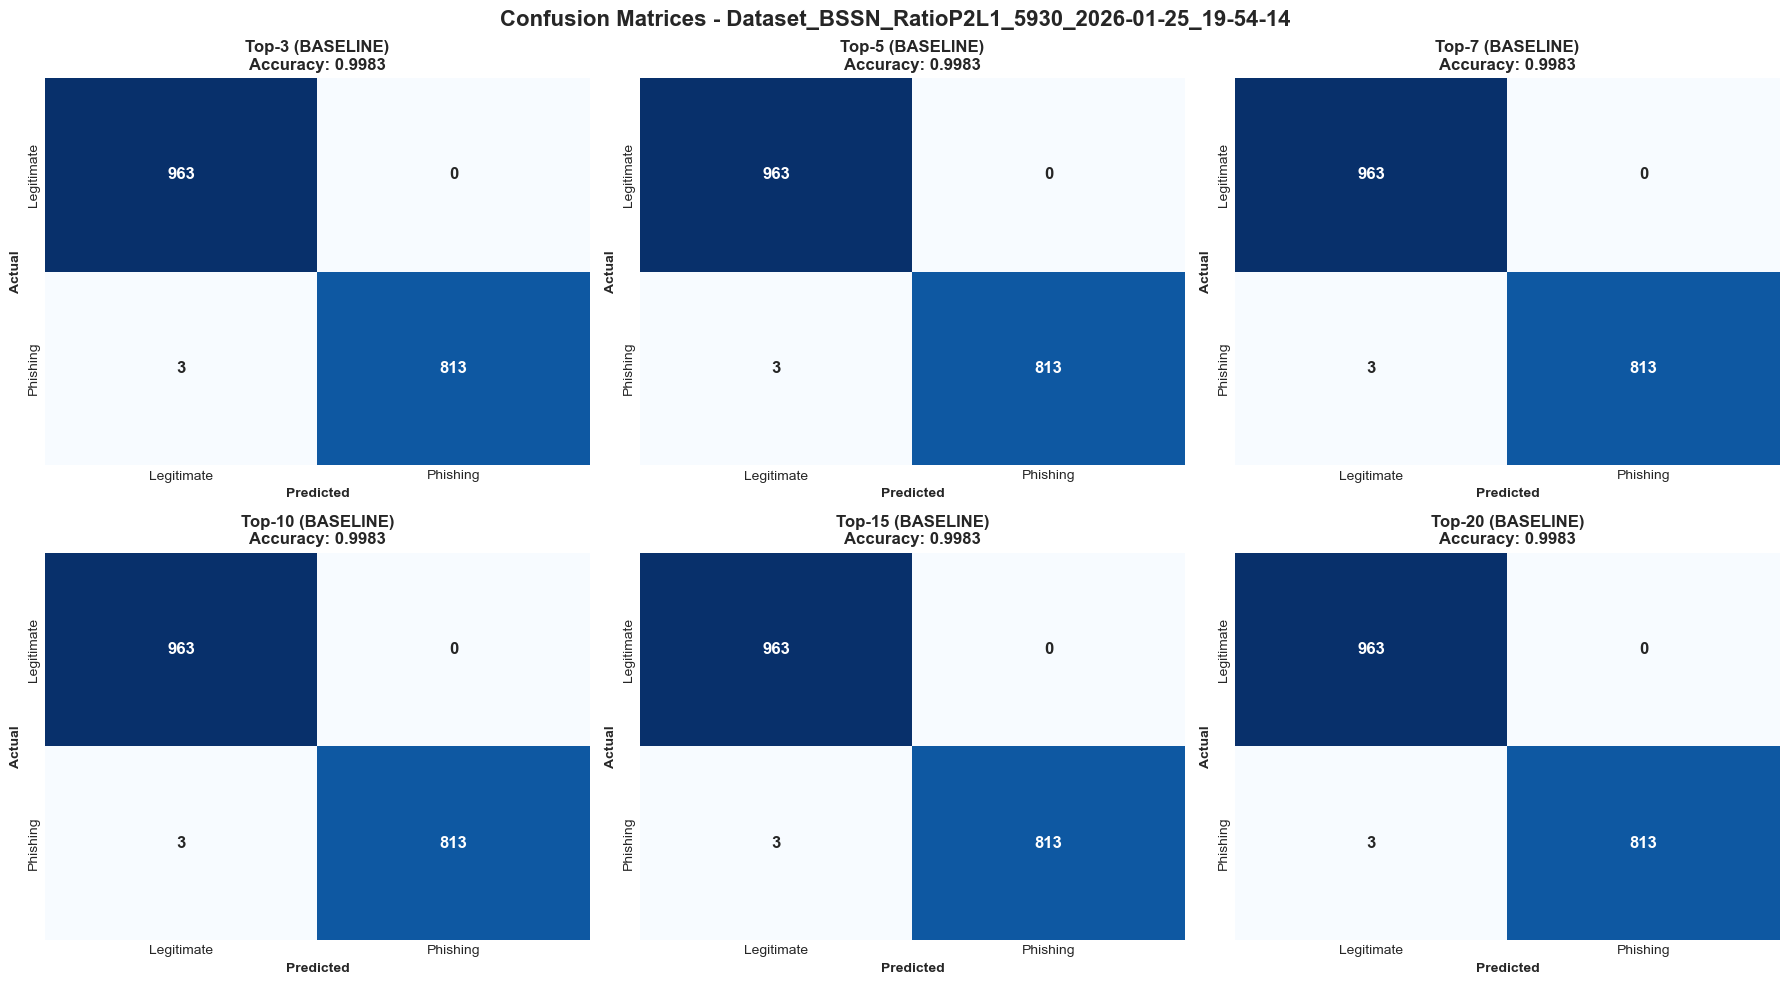

Confusion matrices visualization complete for Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

Generating confusion matrices for Dataset_Crawling_Shuffle_2026-01-14_15-36-26...


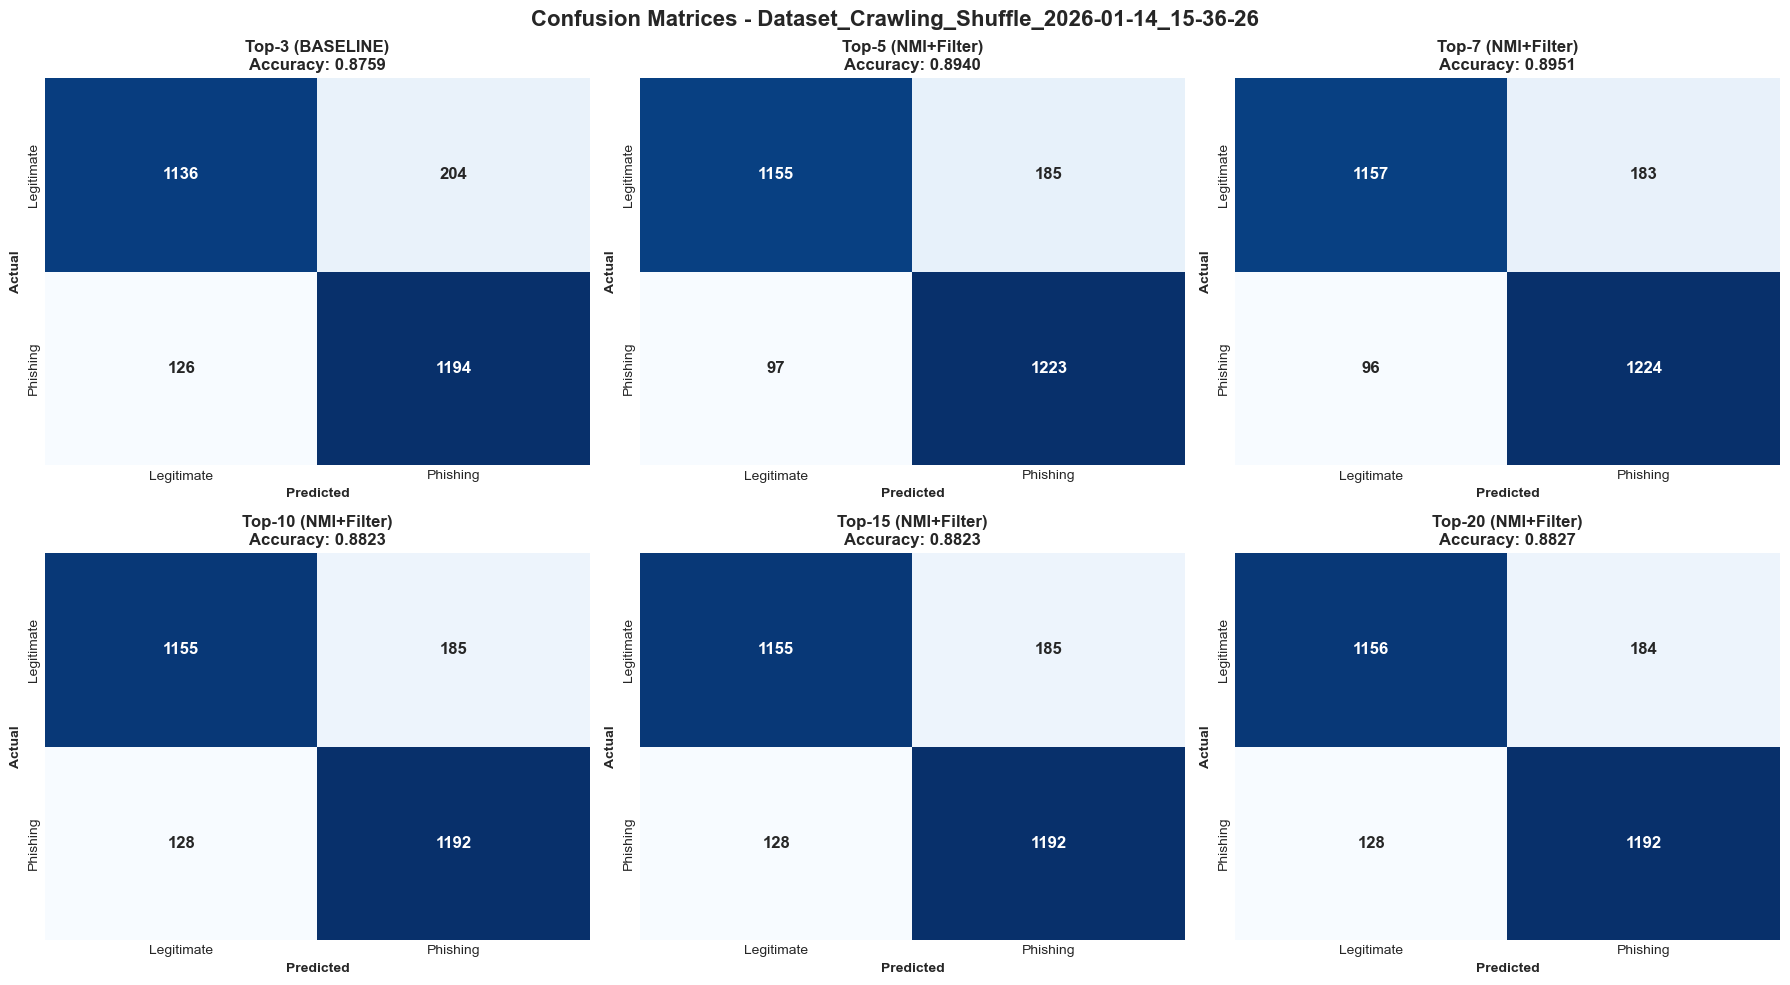

Confusion matrices visualization complete for Dataset_Crawling_Shuffle_2026-01-14_15-36-26

Generating confusion matrices for Dataset_Gabung_Merged_14780_2026-01-17_16-26-33...


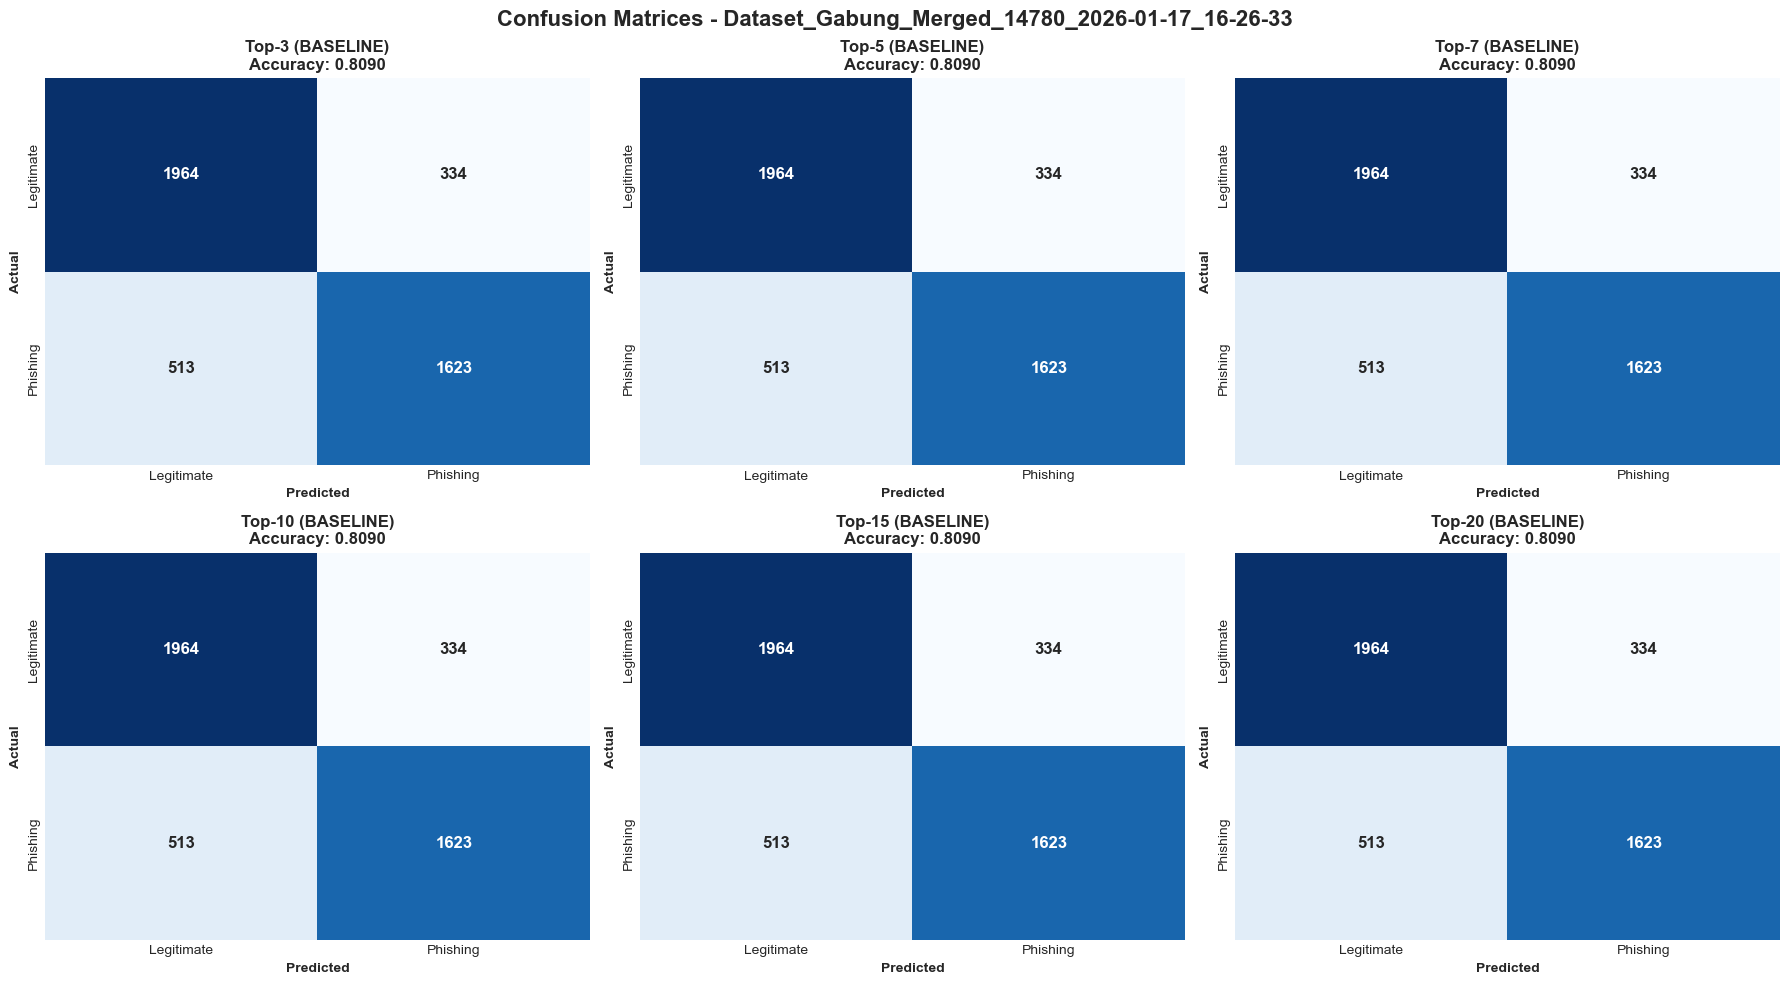

Confusion matrices visualization complete for Dataset_Gabung_Merged_14780_2026-01-17_16-26-33


In [12]:
for dataset in final_results['Dataset'].unique():
    print(f"\nGenerating confusion matrices for {dataset}...")
    
    dataset_results = final_results[final_results['Dataset'] == dataset]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Confusion Matrices - {dataset}', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for idx, top_n in enumerate(TOP_N_VALUES):
        top_n_data = dataset_results[dataset_results['Top_N'] == top_n]
        
        best_idx = top_n_data['F1'].idxmax()
        best_result = top_n_data.loc[best_idx]
        
        cm = np.array([[best_result['TN'], best_result['FP']],
                      [best_result['FN'], best_result['TP']]], dtype=int)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                   xticklabels=['Legitimate', 'Phishing'],
                   yticklabels=['Legitimate', 'Phishing'],
                   cbar=False,
                   annot_kws={'size': 12, 'weight': 'bold'})
        
        axes[idx].set_title(f'Top-{top_n} ({best_result["Model"]})\nAccuracy: {best_result["Accuracy"]:.4f}', 
                           fontweight='bold')
        axes[idx].set_ylabel('Actual', fontweight='bold')
        axes[idx].set_xlabel('Predicted', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    print(f"Confusion matrices visualization complete for {dataset}")

## 9. Feature Importance Analysis

In [13]:
print("\n" + "=" * 150)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 150)

for dataset in final_results['Dataset'].unique():
    print(f"\n{'=' * 150}")
    print(f"DATASET: {dataset}")
    print(f"{'=' * 150}")
    
    dataset_results = final_results[final_results['Dataset'] == dataset]
    
    all_nmi_features = []
    all_mi_features = []
    
    for idx, row in dataset_results.iterrows():
        if row['Model'] in ['BASELINE', 'NMI', 'NMI+Filter']:
            if isinstance(row['Selected_Features'], list):
                if 'NMI' in row['Model']:
                    all_nmi_features.extend(row['Selected_Features'])
        elif row['Model'] in ['MI', 'MI+Filter']:
            if isinstance(row['Selected_Features'], list):
                all_mi_features.extend(row['Selected_Features'])
    
    nmi_feature_counts = pd.Series(all_nmi_features).value_counts()
    mi_feature_counts = pd.Series(all_mi_features).value_counts()
    
    print("\nMost Important Features by NMI (across all Top-N configurations):")
    print(nmi_feature_counts.head(10).to_string())
    
    print("\n\nMost Important Features by MI (across all Top-N configurations):")
    print(mi_feature_counts.head(10).to_string())
    
    print("\n\nFeature Selection Consistency:")
    print(f"  NMI method selected {len(set(all_nmi_features))} unique features across all Top-N")
    print(f"  MI method selected {len(set(all_mi_features))} unique features across all Top-N")
    
    overlap = set(nmi_feature_counts.index) & set(mi_feature_counts.index)
    print(f"  Features selected by BOTH methods: {len(overlap)}")
    print(f"  Overlap: {', '.join(list(overlap)[:5])}..." if overlap else "  No overlap")


FEATURE IMPORTANCE ANALYSIS

DATASET: Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

Most Important Features by NMI (across all Top-N configurations):
SlashCountPath       12
PathLength           12
SlashCountURL        12
Entropy              10
UrlLength            10
HyphenCountURL        8
HyphenCountDomain     8
DomainLength          6
DotCountURL           6
DotCountDomain        6


Most Important Features by MI (across all Top-N configurations):
SlashCountPath       12
SlashCountURL        12
PathLength           12
Entropy              10
UrlLength            10
DomainLength          8
HyphenCountURL        8
HyphenCountDomain     6
DotCountURL           6
DotCountDomain        6


Feature Selection Consistency:
  NMI method selected 20 unique features across all Top-N
  MI method selected 20 unique features across all Top-N
  Features selected by BOTH methods: 19
  Overlap: SlashCountPath, DotCountURL, HashtagCountQuery, UrlLength, CommaCountPath...

DATASET: Dataset_Crawl

## 10. Final Summary Report

In [14]:
print("\n" + "=" * 150)
print("EXECUTIVE SUMMARY: KEY FINDINGS & RECOMMENDATIONS")
print("=" * 150)

for dataset in final_results['Dataset'].unique():
    print(f"\n{'=' * 150}")
    print(f"{dataset}")
    print(f"{'=' * 150}\n")
    
    dataset_results = final_results[final_results['Dataset'] == dataset]
    
    print("1. BEST OVERALL PERFORMANCE:")
    best_overall = dataset_results.loc[dataset_results['F1'].idxmax()]
    print(f"   Model: {best_overall['Model']}")
    print(f"   Top-N: {int(best_overall['Top_N'])}")
    print(f"   F1-Score: {best_overall['F1']:.4f}")
    print(f"   Accuracy: {best_overall['Accuracy']:.4f}")
    print(f"   Precision: {best_overall['Precision']:.4f}")
    print(f"   Recall: {best_overall['Recall']:.4f}")
    
    print("\n2. COMPARISON BY FEATURE SELECTION METHOD:")
    
    for model in ['BASELINE', 'NMI', 'NMI+Filter', 'MI', 'MI+Filter']:
        model_results = dataset_results[dataset_results['Model'] == model]
        if len(model_results) > 0:
            best = model_results.loc[model_results['F1'].idxmax()]
            print(f"   {model:15} → Top-{int(best['Top_N'])}: F1={best['F1']:.4f}, Accuracy={best['Accuracy']:.4f}")
    
    print("\n3. IMPACT OF WHITELISTING (NMI+Filter vs NMI):")
    nmi_results = dataset_results[dataset_results['Model'] == 'NMI']
    nmi_filter_results = dataset_results[dataset_results['Model'] == 'NMI+Filter']
    
    if len(nmi_results) > 0 and len(nmi_filter_results) > 0:
        best_nmi = nmi_results.loc[nmi_results['F1'].idxmax()]
        best_filter = nmi_filter_results.loc[nmi_filter_results['F1'].idxmax()]
        
        f1_diff = best_filter['F1'] - best_nmi['F1']
        print(f"   Without Filter (NMI): F1={best_nmi['F1']:.4f}")
        print(f"   With Filter (NMI+Filter): F1={best_filter['F1']:.4f}")
        print(f"   Difference: {f1_diff:+.4f}")
        
        if 'Whitelisted_URLs' in best_filter and pd.notna(best_filter['Whitelisted_URLs']):
            whitelisted = int(best_filter['Whitelisted_URLs'])
            total = int(best_filter['TN']) + int(best_filter['FP']) + int(best_filter['FN']) + int(best_filter['TP'])
            pct = (whitelisted / total * 100) if total > 0 else 0
            print(f"   URLs auto-classified as legitimate: {whitelisted:,} ({pct:.2f}%)")
    
    print("\n4. ERROR RATES:")
    best_model = dataset_results.loc[dataset_results['F1'].idxmax()]
    
    tn, fp, fn, tp = int(best_model['TN']), int(best_model['FP']), int(best_model['FN']), int(best_model['TP'])
    metrics = calculate_error_metrics(tn, fp, fn, tp)
    
    print(f"   Type I Error (False Positive): {metrics['Type_I_Error']:,} URLs")
    print(f"   Type II Error (False Negative): {metrics['Type_II_Error']:,} URLs")
    print(f"   False Positive Rate: {metrics['FPR']:.4f}")
    print(f"   False Negative Rate: {metrics['FNR']:.4f}")
    print(f"   Sensitivity (Detect Phishing): {metrics['Sensitivity']:.4f}")
    print(f"   Specificity (Detect Legitimate): {metrics['Specificity']:.4f}")
    
    print("\n5. FEATURE EFFICIENCY:")
    
    baseline_results = dataset_results[dataset_results['Model'] == 'BASELINE']
    baseline_f1 = baseline_results['F1'].iloc[0] if len(baseline_results) > 0 else 0
    
    nmi_results = dataset_results[dataset_results['Model'] == 'NMI']
    mi_results = dataset_results[dataset_results['Model'] == 'MI']
    
    best_nmi_f1 = nmi_results['F1'].max() if len(nmi_results) > 0 else 0
    best_mi_f1 = mi_results['F1'].max() if len(mi_results) > 0 else 0
    
    best_nmi_idx = nmi_results['F1'].idxmax() if len(nmi_results) > 0 else None
    best_mi_idx = mi_results['F1'].idxmax() if len(mi_results) > 0 else None
    
    best_nmi_top_n = dataset_results.loc[best_nmi_idx, 'Top_N'] if best_nmi_idx is not None else 0
    best_mi_top_n = dataset_results.loc[best_mi_idx, 'Top_N'] if best_mi_idx is not None else 0
    
    print(f"   Baseline (All 17 features): F1={baseline_f1:.4f}")
    print(f"   NMI (Top-{int(best_nmi_top_n)} features): F1={best_nmi_f1:.4f} "
          f"({int(best_nmi_top_n)}/17 = {best_nmi_top_n/17*100:.1f}% of features)" if best_nmi_top_n > 0 else "   NMI: No results")
    print(f"   MI (Top-{int(best_mi_top_n)} features): F1={best_mi_f1:.4f} "
          f"({int(best_mi_top_n)}/17 = {best_mi_top_n/17*100:.1f}% of features)" if best_mi_top_n > 0 else "   MI: No results")
    
    print("\n6. RECOMMENDATION:")
    
    if metrics['Sensitivity'] > metrics['Specificity']:
        print("   → Model prioritizes detecting phishing URLs (higher sensitivity)")
        print("   → Suitable for high-risk environments requiring phishing protection")
    else:
        print("   → Model prioritizes detecting legitimate URLs (higher specificity)")
        print("   → Suitable for environments with many false positive concerns")
    
    best_features = int(best_model['Top_N'])
    if best_features < 10:
        print(f"   → Use Top-{best_features} features for optimal performance with minimal features")
    else:
        print(f"   → All Top-N configurations (3-20) perform well; choose based on time/performance trade-off")


EXECUTIVE SUMMARY: KEY FINDINGS & RECOMMENDATIONS

Dataset_BSSN_RatioP2L1_5930_2026-01-25_19-54-14

1. BEST OVERALL PERFORMANCE:
   Model: BASELINE
   Top-N: 3
   F1-Score: 0.9982
   Accuracy: 0.9983
   Precision: 1.0000
   Recall: 0.9963

2. COMPARISON BY FEATURE SELECTION METHOD:
   BASELINE        → Top-3: F1=0.9982, Accuracy=0.9983
   NMI             → Top-10: F1=0.9982, Accuracy=0.9983
   NMI+Filter      → Top-10: F1=0.9982, Accuracy=0.9983
   MI              → Top-7: F1=0.9982, Accuracy=0.9983
   MI+Filter       → Top-7: F1=0.9982, Accuracy=0.9983

3. IMPACT OF WHITELISTING (NMI+Filter vs NMI):
   Without Filter (NMI): F1=0.9982
   With Filter (NMI+Filter): F1=0.9982
   Difference: +0.0000
   URLs auto-classified as legitimate: 422 (23.72%)

4. ERROR RATES:
   Type I Error (False Positive): 0 URLs
   Type II Error (False Negative): 3 URLs
   False Positive Rate: 0.0000
   False Negative Rate: 0.0037
   Sensitivity (Detect Phishing): 0.9963
   Specificity (Detect Legitimate): 1.0

## 11. Export Results to Markdown Report

In [15]:
from datetime import datetime
import os

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_folder = '3dt_Langsung_Hasil'
os.makedirs(output_folder, exist_ok=True)

md_content = f"""# Comprehensive Phishing Detection Analysis Report

**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Summary

- **Datasets Analyzed:** {final_results['Dataset'].nunique()}
- **Models Evaluated:** {final_results['Model'].nunique()}
- **Methods:** BASELINE, NMI, NMI+Filter, MI, MI+Filter
- **Top-N Values:** 3, 5, 7, 10, 15, 20
- **Total Configurations:** {len(final_results)}
- **Total Features Used:** 52+ (Entropy, URL Features, Domain Features, Path Features, Query Features)

---

"""

for dataset in sorted(final_results['Dataset'].unique()):
    dataset_results = final_results[final_results['Dataset'] == dataset]
    best_overall = dataset_results.loc[dataset_results['F1'].idxmax()]
    
    md_content += f"\n## {dataset}\n\n"
    md_content += f"**Best Model:** {best_overall['Model']} (Top-{int(best_overall['Top_N'])}) | **F1-Score:** {best_overall['F1']:.4f}\n\n"
    
    for top_n in sorted(dataset_results['Top_N'].unique()):
        top_n_data = dataset_results[dataset_results['Top_N'] == top_n]
        md_content += f"### Top-{int(top_n)} Features\n\n"
        md_content += "| Model | Accuracy | Precision | Recall | F1 | TN | FP | FN | TP | Bypassed URLs | ML-Classified |\n"
        md_content += "|-------|----------|-----------|--------|----|----|----|----|------|---------------|----------------|\n"
        
        for _, row in top_n_data.iterrows():
            bypassed_str = "N/A"
            ml_class_str = "N/A"
            if 'Whitelisted_URLs' in row and pd.notna(row['Whitelisted_URLs']):
                whitelisted = int(row['Whitelisted_URLs'])
                ml_classified = int(row['ML_Classified_URLs'])
                total = ml_classified + whitelisted
                whitelisted_pct = (whitelisted / total * 100) if total > 0 else 0
                bypassed_str = f"{whitelisted:,} ({whitelisted_pct:.1f}%)"
                ml_class_str = f"{ml_classified:,}"
            
            md_content += f"| {row['Model']} | {row['Accuracy']:.4f} | {row['Precision']:.4f} | {row['Recall']:.4f} | {row['F1']:.4f} | {int(row['TN']):,} | {int(row['FP']):,} | {int(row['FN']):,} | {int(row['TP']):,} | {bypassed_str} | {ml_class_str} |\n"
        
        md_content += "\n"
        
        # Add selected features section for each Top-N
        md_content += f"#### Selected Features for Top-{int(top_n)}\n\n"
        
        for _, row in top_n_data.iterrows():
            model_name = row['Model']
            selected_features = row['Selected_Features']
            
            if isinstance(selected_features, list):
                features_str = ', '.join(selected_features)
                md_content += f"**{model_name}** ({len(selected_features)} features):\n"
                md_content += f"> {features_str}\n\n"
            else:
                md_content += f"**{model_name}**: N/A\n\n"
        
        md_content += "\n"

md_path = os.path.join(output_folder, f'comprehensive_analysis_results_{timestamp}.md')
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md_content)

print("\n" + "=" * 150)
print("RESULTS EXPORTED TO MARKDOWN")
print("=" * 150)
print(f"\nFolder created: {output_folder}")
print(f"File saved: {md_path}")
print(f"Total records: {len(final_results)}")
print(f"Datasets: {final_results['Dataset'].nunique()}")
print(f"Models: {final_results['Model'].nunique()}")
print(f"Configurations: {len(final_results)}")
print(f"\nMarkdown Report Includes:")
print(f"  ✓ All models performance metrics (Accuracy, Precision, Recall, F1)")
print(f"  ✓ Whitelist+Entropy bypass counts with percentages")
print(f"  ✓ ML-Classified URLs count for comparison")
print(f"  ✓ Confusion matrix values (TN, FP, FN, TP)")
print(f"  ✓ Best model for each Top-N configuration")
print(f"  ✓ Complete list of selected features for each model at each Top-N")
print(f"\nNow open folder '{output_folder}' → open '{os.path.basename(md_path)}' in markdown viewer")


RESULTS EXPORTED TO MARKDOWN

Folder created: 3dt_Langsung_Hasil
File saved: 3dt_Langsung_Hasil\comprehensive_analysis_results_20260512_131102.md
Total records: 90
Datasets: 3
Models: 5
Configurations: 90

Markdown Report Includes:
  ✓ All models performance metrics (Accuracy, Precision, Recall, F1)
  ✓ Whitelist+Entropy bypass counts with percentages
  ✓ ML-Classified URLs count for comparison
  ✓ Confusion matrix values (TN, FP, FN, TP)
  ✓ Best model for each Top-N configuration
  ✓ Complete list of selected features for each model at each Top-N

Now open folder '3dt_Langsung_Hasil' → open 'comprehensive_analysis_results_20260512_131102.md' in markdown viewer


## 12. Comprehensive Visualization - Model Comparison Across All Datasets & Scenarios


GENERATING COMPREHENSIVE VISUALIZATIONS
✓ Saved: 01_metrics_comparison_all_models.png


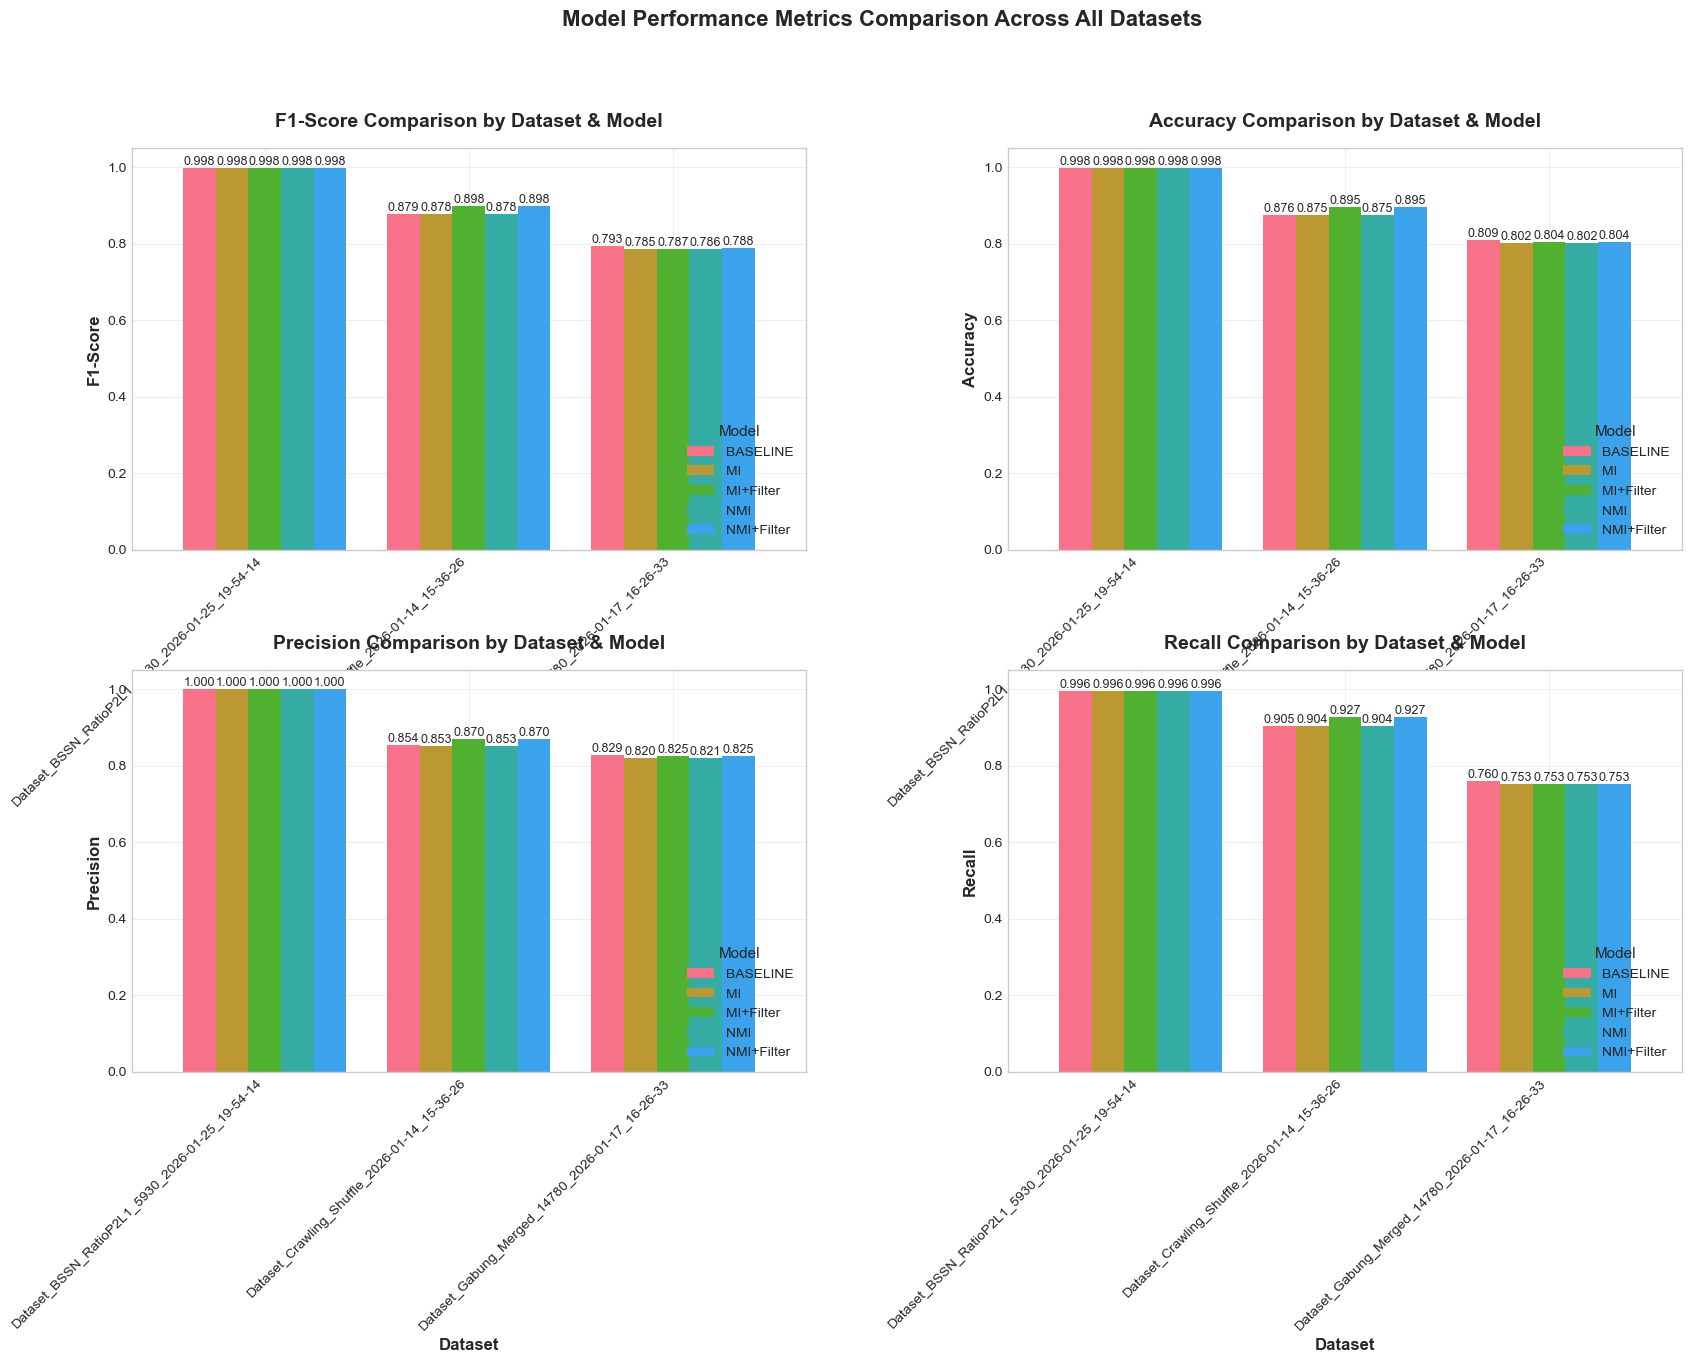

✓ Saved: 02_f1_heatmap_all_models.png


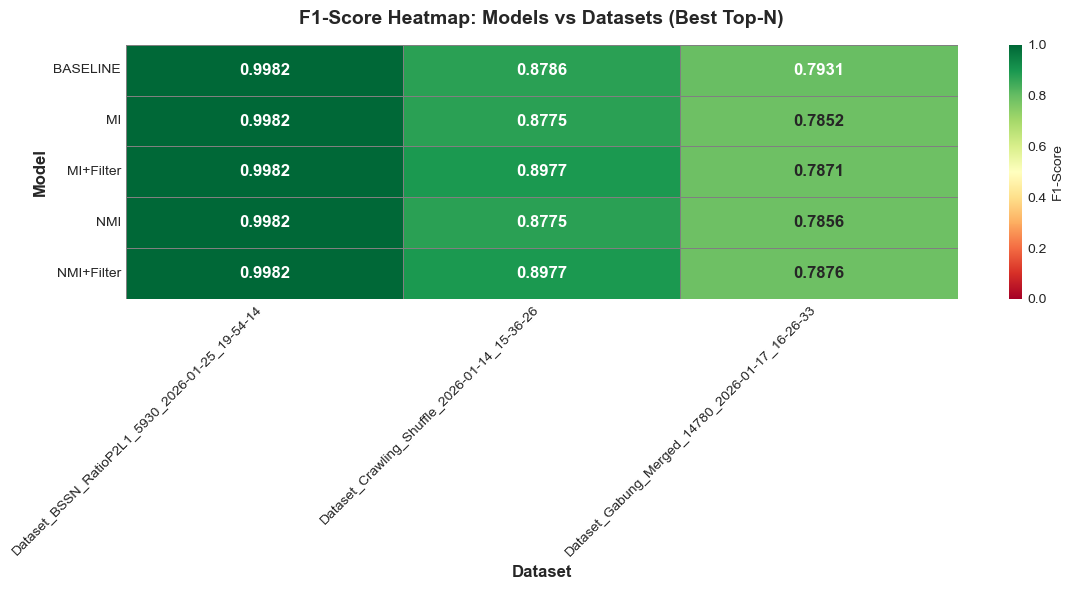

✓ Saved: 03_topn_comparison_BSSN.png


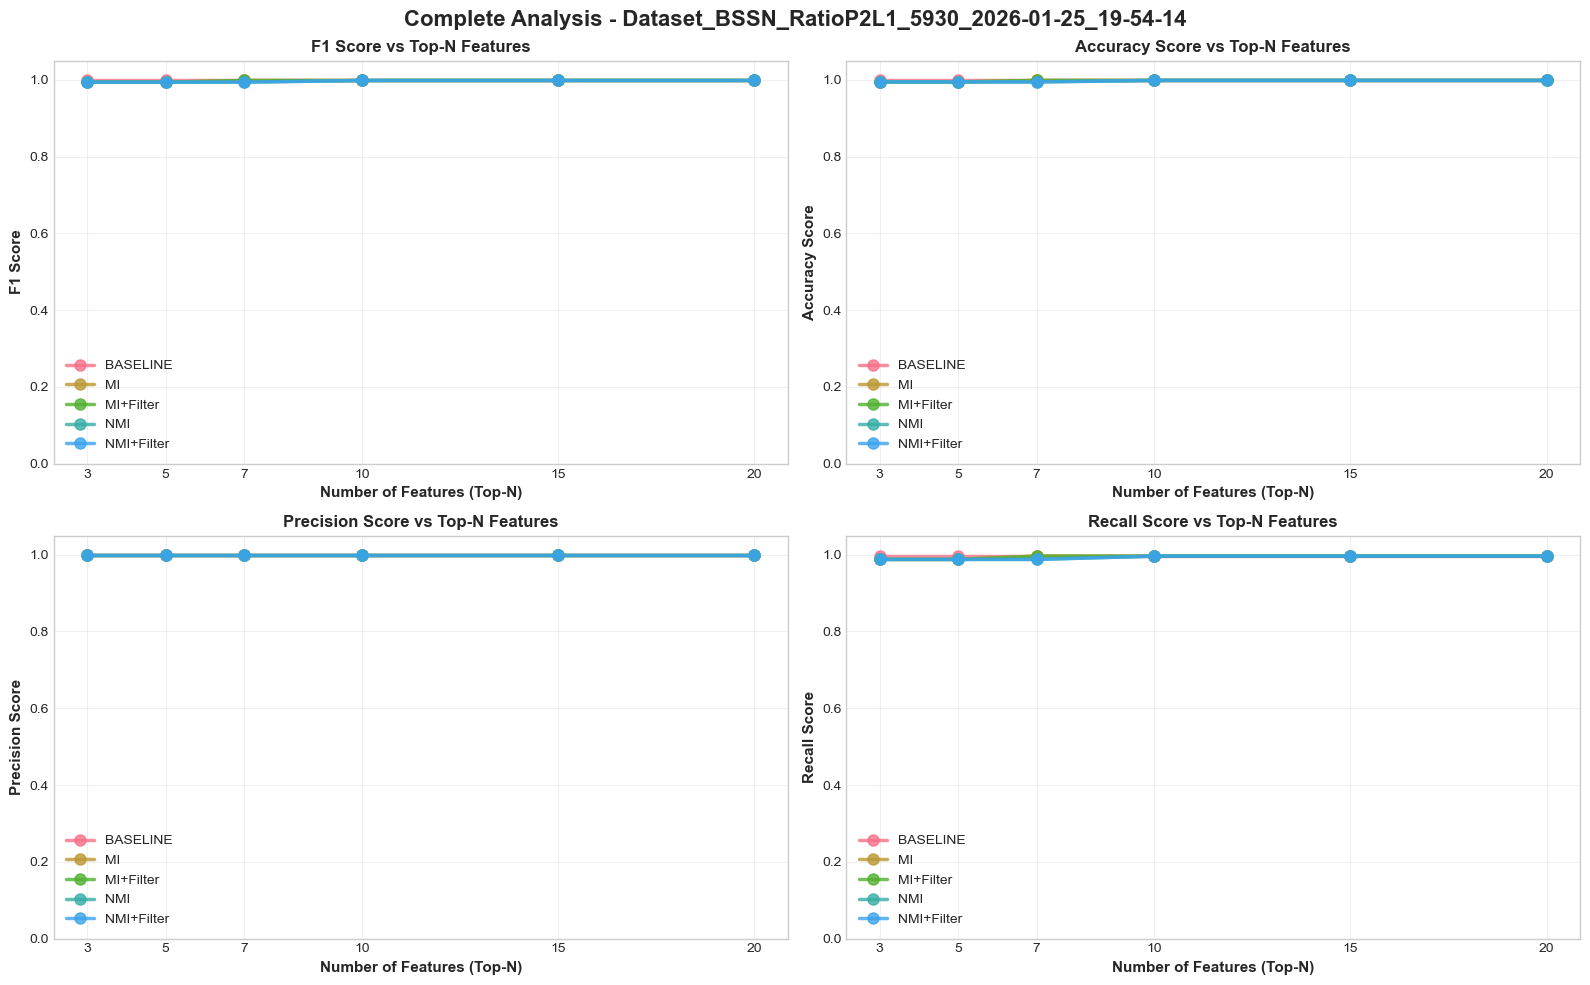

✓ Saved: 03_topn_comparison_Crawling.png


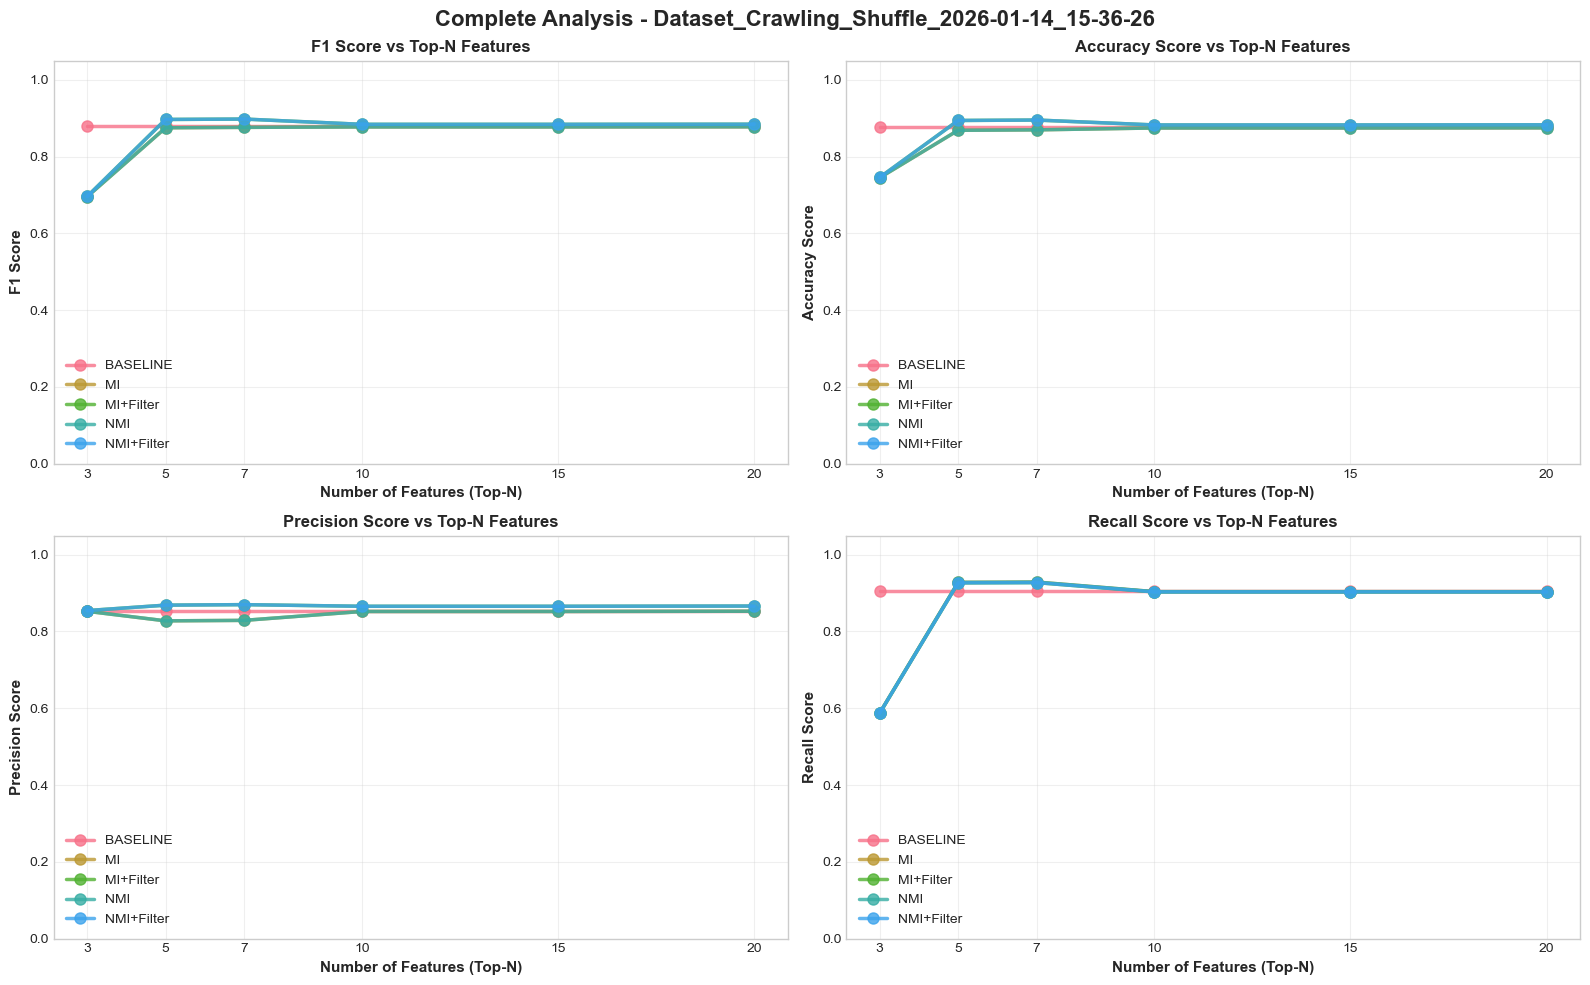

✓ Saved: 03_topn_comparison_Gabung.png


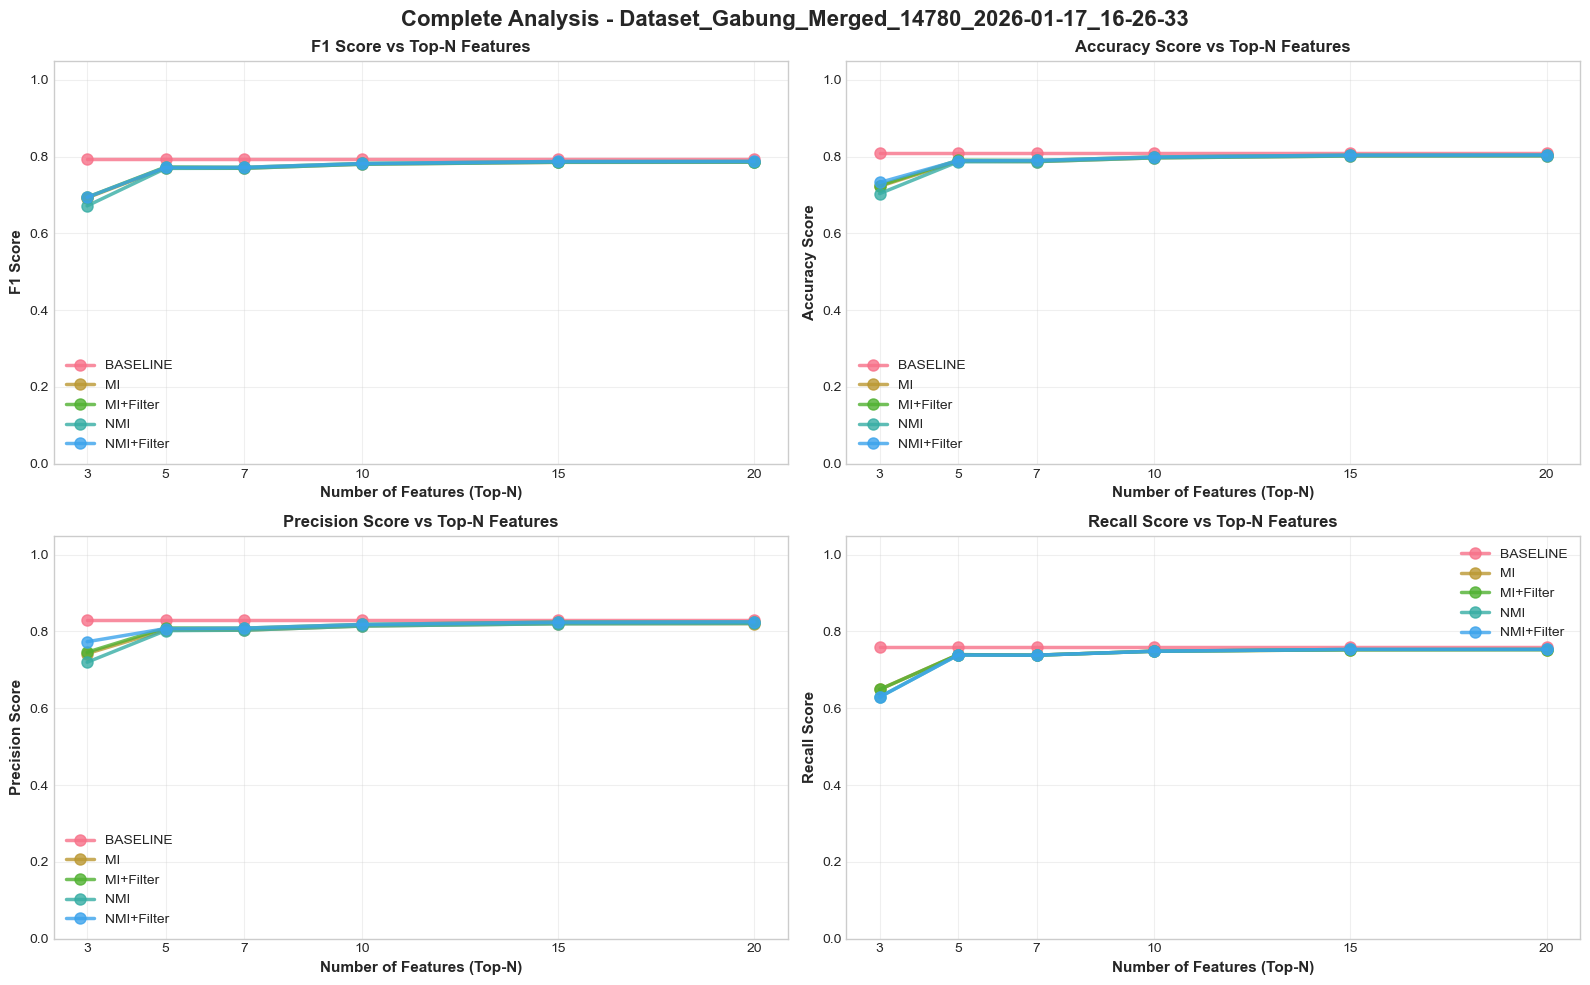

✓ Saved: 04_model_comparison_BSSN.png


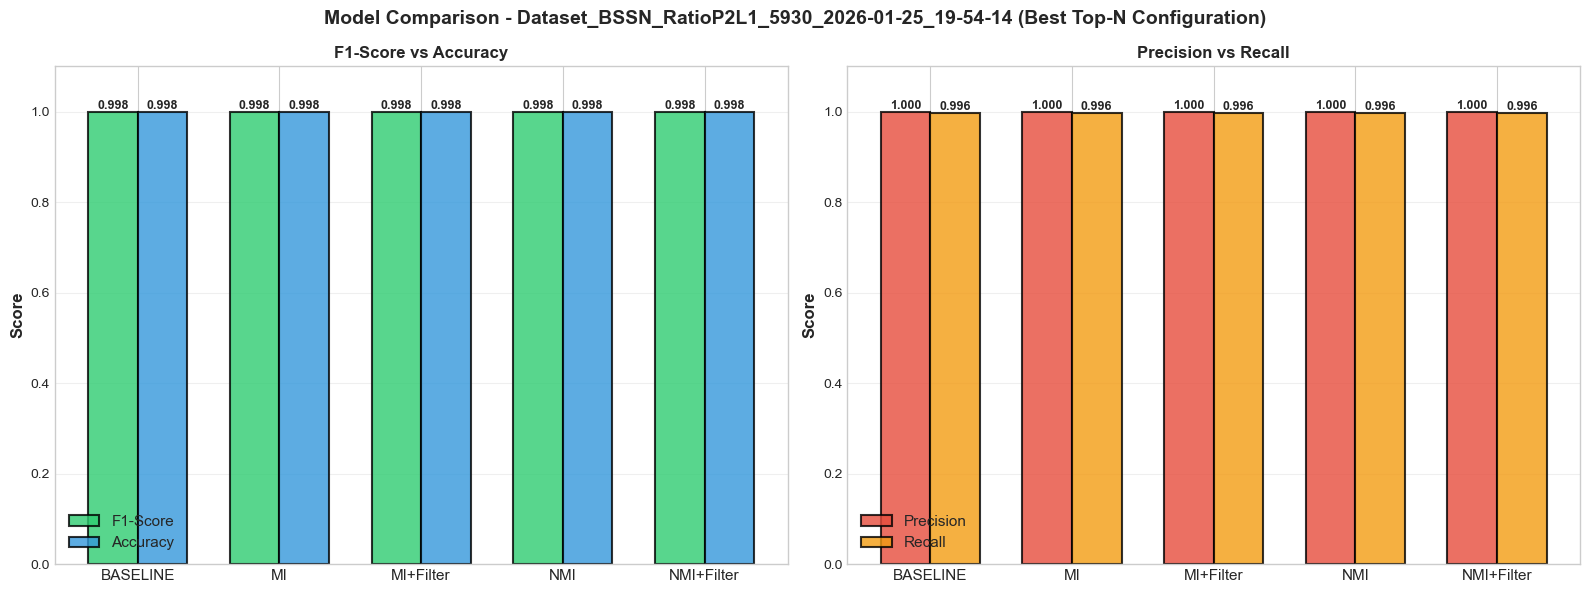

✓ Saved: 04_model_comparison_Crawling.png


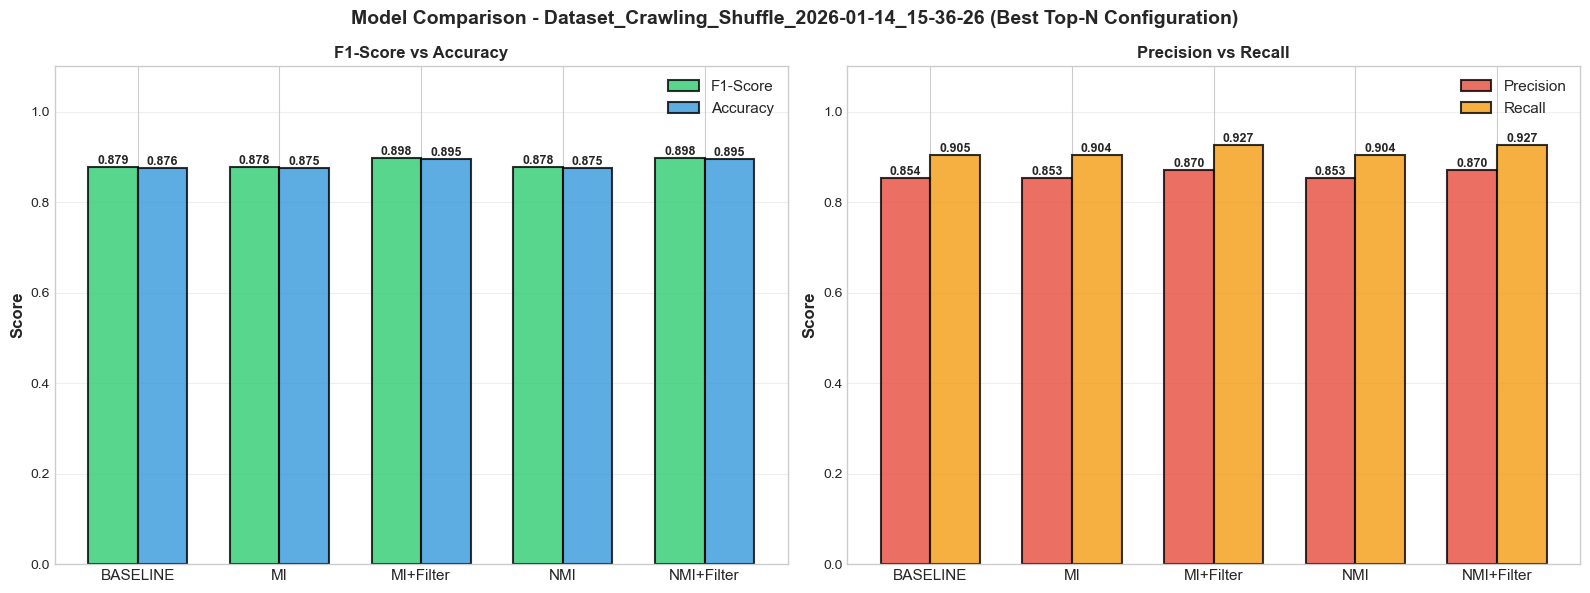

✓ Saved: 04_model_comparison_Gabung.png


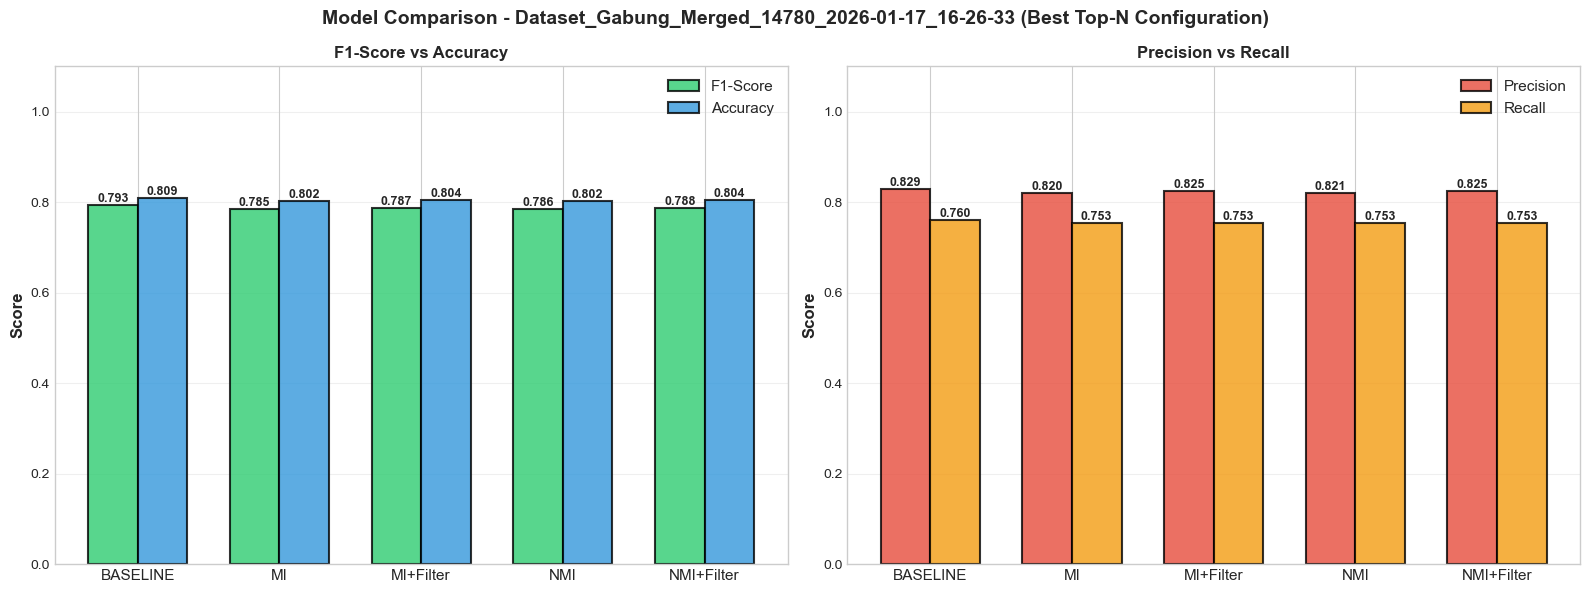


ALL VISUALIZATIONS GENERATED SUCCESSFULLY!

Graphs saved in: 3dt_Langsung_Hasil/

Generated Files:
  1. 01_metrics_comparison_all_models.png - Comprehensive metrics comparison
  2. 02_f1_heatmap_all_models.png - F1-Score heatmap
  3. 03_topn_comparison_*.png - Top-N performance curves for each dataset
  4. 04_model_comparison_*.png - Model-to-model comparison for each dataset


In [16]:
"""
COMPREHENSIVE VISUALIZATION FOR ALL DATASETS & SCENARIOS
Visualisasi perbandingan model dengan berbagai metrik
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("\n" + "=" * 150)
print("GENERATING COMPREHENSIVE VISUALIZATIONS")
print("=" * 150)

# ============================================================================
# 1. F1-SCORE COMPARISON ACROSS ALL MODELS & DATASETS
# ============================================================================

# Get best Top-N for each model-dataset combination
best_results_by_model_dataset = final_results.loc[final_results.groupby(['Dataset', 'Model'])['F1'].idxmax()]

# Create pivot tables for visualization
f1_pivot = best_results_by_model_dataset.pivot_table(
    values='F1', 
    index='Model', 
    columns='Dataset',
    aggfunc='first'
)

accuracy_pivot = best_results_by_model_dataset.pivot_table(
    values='Accuracy', 
    index='Model', 
    columns='Dataset',
    aggfunc='first'
)

precision_pivot = best_results_by_model_dataset.pivot_table(
    values='Precision', 
    index='Model', 
    columns='Dataset',
    aggfunc='first'
)

recall_pivot = best_results_by_model_dataset.pivot_table(
    values='Recall', 
    index='Model', 
    columns='Dataset',
    aggfunc='first'
)

# Create comprehensive comparison figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. F1-Score Comparison
ax1 = fig.add_subplot(gs[0, 0])
f1_pivot.T.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('F1-Score Comparison by Dataset & Model', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax1.legend(title='Model', fontsize=10, title_fontsize=11, loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
# Add value labels on bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', fontsize=9)

# 2. Accuracy Comparison
ax2 = fig.add_subplot(gs[0, 1])
accuracy_pivot.T.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Accuracy Comparison by Dataset & Model', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax2.legend(title='Model', fontsize=10, title_fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', fontsize=9)

# 3. Precision Comparison
ax3 = fig.add_subplot(gs[1, 0])
precision_pivot.T.plot(kind='bar', ax=ax3, width=0.8)
ax3.set_title('Precision Comparison by Dataset & Model', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax3.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax3.legend(title='Model', fontsize=10, title_fontsize=11, loc='lower right')
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1.05])
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.3f', fontsize=9)

# 4. Recall Comparison
ax4 = fig.add_subplot(gs[1, 1])
recall_pivot.T.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('Recall Comparison by Dataset & Model', fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax4.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax4.legend(title='Model', fontsize=10, title_fontsize=11, loc='lower right')
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1.05])
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
for container in ax4.containers:
    ax4.bar_label(container, fmt='%.3f', fontsize=9)

plt.suptitle('Model Performance Metrics Comparison Across All Datasets', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{output_folder}/01_metrics_comparison_all_models.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 01_metrics_comparison_all_models.png")
plt.show()

# ============================================================================
# 2. HEATMAP - F1-SCORE ACROSS ALL MODELS & DATASETS
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Create heatmap with better styling
sns.heatmap(f1_pivot, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'F1-Score'},
            linewidths=0.5, linecolor='gray', ax=ax, vmin=0, vmax=1, 
            cbar=True, square=False, annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title('F1-Score Heatmap: Models vs Datasets (Best Top-N)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_folder}/02_f1_heatmap_all_models.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_f1_heatmap_all_models.png")
plt.show()

# ============================================================================
# 3. MODEL COMPARISON FOR EACH DATASET WITH ALL TOP-N VALUES
# ============================================================================

for dataset in sorted(final_results['Dataset'].unique()):
    dataset_data = final_results[final_results['Dataset'] == dataset]
    
    # Prepare data for visualization
    models = sorted(dataset_data['Model'].unique())
    top_ns = sorted(dataset_data['Top_N'].unique())
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Complete Analysis - {dataset}', fontsize=16, fontweight='bold')
    
    metrics = ['F1', 'Accuracy', 'Precision', 'Recall']
    
    for idx, (ax, metric) in enumerate(zip(axes.flat, metrics)):
        for model in models:
            model_data = dataset_data[dataset_data['Model'] == model]
            model_data = model_data.sort_values('Top_N')
            
            ax.plot(model_data['Top_N'].astype(int), model_data[metric], 
                   marker='o', linewidth=2.5, markersize=8, label=model, alpha=0.8)
        
        ax.set_title(f'{metric} Score vs Top-N Features', fontsize=12, fontweight='bold')
        ax.set_xlabel('Number of Features (Top-N)', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{metric} Score', fontsize=11, fontweight='bold')
        ax.set_xticks(top_ns)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10, loc='best')
        ax.set_ylim([0, 1.05])
    
    plt.tight_layout()
    dataset_name_short = dataset.split('_')[1] if '_' in dataset else dataset[:15]
    plt.savefig(f'{output_folder}/03_topn_comparison_{dataset_name_short}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: 03_topn_comparison_{dataset_name_short}.png")
    plt.show()

# ============================================================================
# 4. MODEL-TO-MODEL COMPARISON (Grouped Bar Charts)
# ============================================================================

for dataset in sorted(final_results['Dataset'].unique()):
    dataset_data = final_results[final_results['Dataset'] == dataset]
    best_results_dataset = dataset_data.loc[dataset_data.groupby('Model')['F1'].idxmax()]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Model Comparison - {dataset} (Best Top-N Configuration)', 
                fontsize=14, fontweight='bold')
    
    # Prepare data
    models = best_results_dataset['Model'].values
    f1_scores = best_results_dataset['F1'].values
    accuracy_scores = best_results_dataset['Accuracy'].values
    top_ns = best_results_dataset['Top_N'].values
    
    # Create color map
    colors = plt.cm.Set3(np.linspace(0, 1, len(models)))
    
    # F1 and Accuracy comparison
    x = np.arange(len(models))
    width = 0.35
    
    ax = axes[0]
    bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, accuracy_scores, width, label='Accuracy', color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('F1-Score vs Accuracy', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Precision and Recall comparison
    precision_scores = best_results_dataset['Precision'].values
    recall_scores = best_results_dataset['Recall'].values
    
    ax = axes[1]
    bars1 = ax.bar(x - width/2, precision_scores, width, label='Precision', color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, recall_scores, width, label='Recall', color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Precision vs Recall', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    dataset_name_short = dataset.split('_')[1] if '_' in dataset else dataset[:15]
    plt.savefig(f'{output_folder}/04_model_comparison_{dataset_name_short}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: 04_model_comparison_{dataset_name_short}.png")
    plt.show()

print("\n" + "=" * 150)
print("ALL VISUALIZATIONS GENERATED SUCCESSFULLY!")
print("=" * 150)
print(f"\nGraphs saved in: {output_folder}/")
print("\nGenerated Files:")
print("  1. 01_metrics_comparison_all_models.png - Comprehensive metrics comparison")
print("  2. 02_f1_heatmap_all_models.png - F1-Score heatmap")
print("  3. 03_topn_comparison_*.png - Top-N performance curves for each dataset")
print("  4. 04_model_comparison_*.png - Model-to-model comparison for each dataset")


## 13. Advanced Comparisons - Error Analysis & Efficiency Metrics


GENERATING ADVANCED VISUALIZATIONS
✓ Saved: 05_error_analysis_BSSN.png


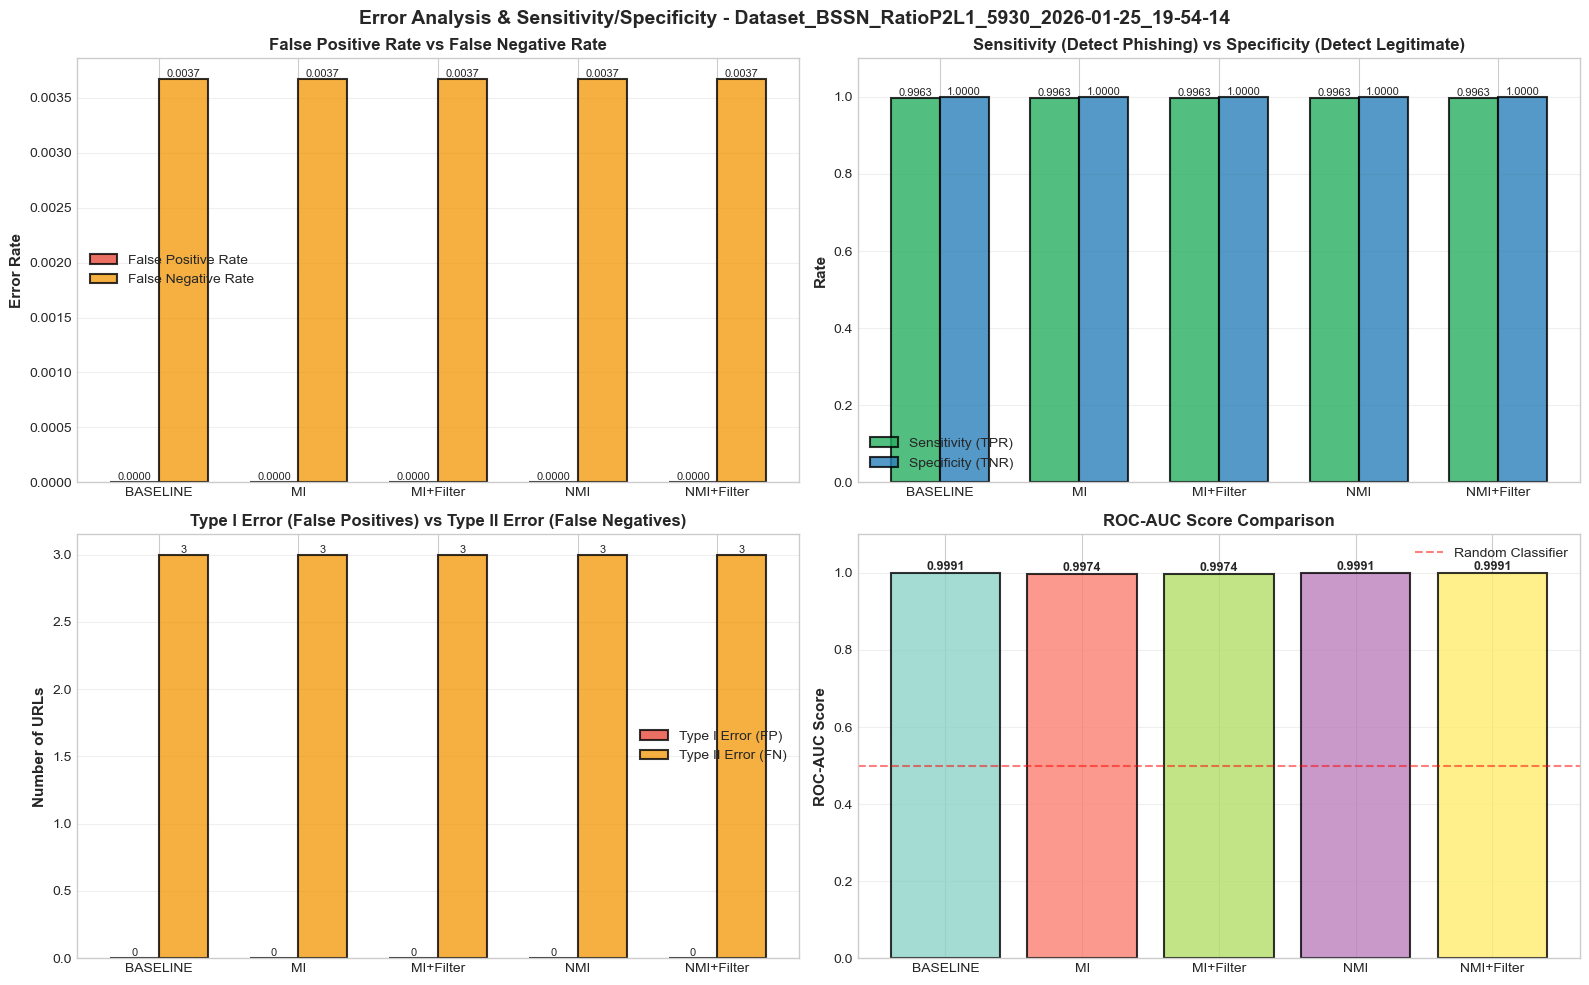

✓ Saved: 05_error_analysis_Crawling.png


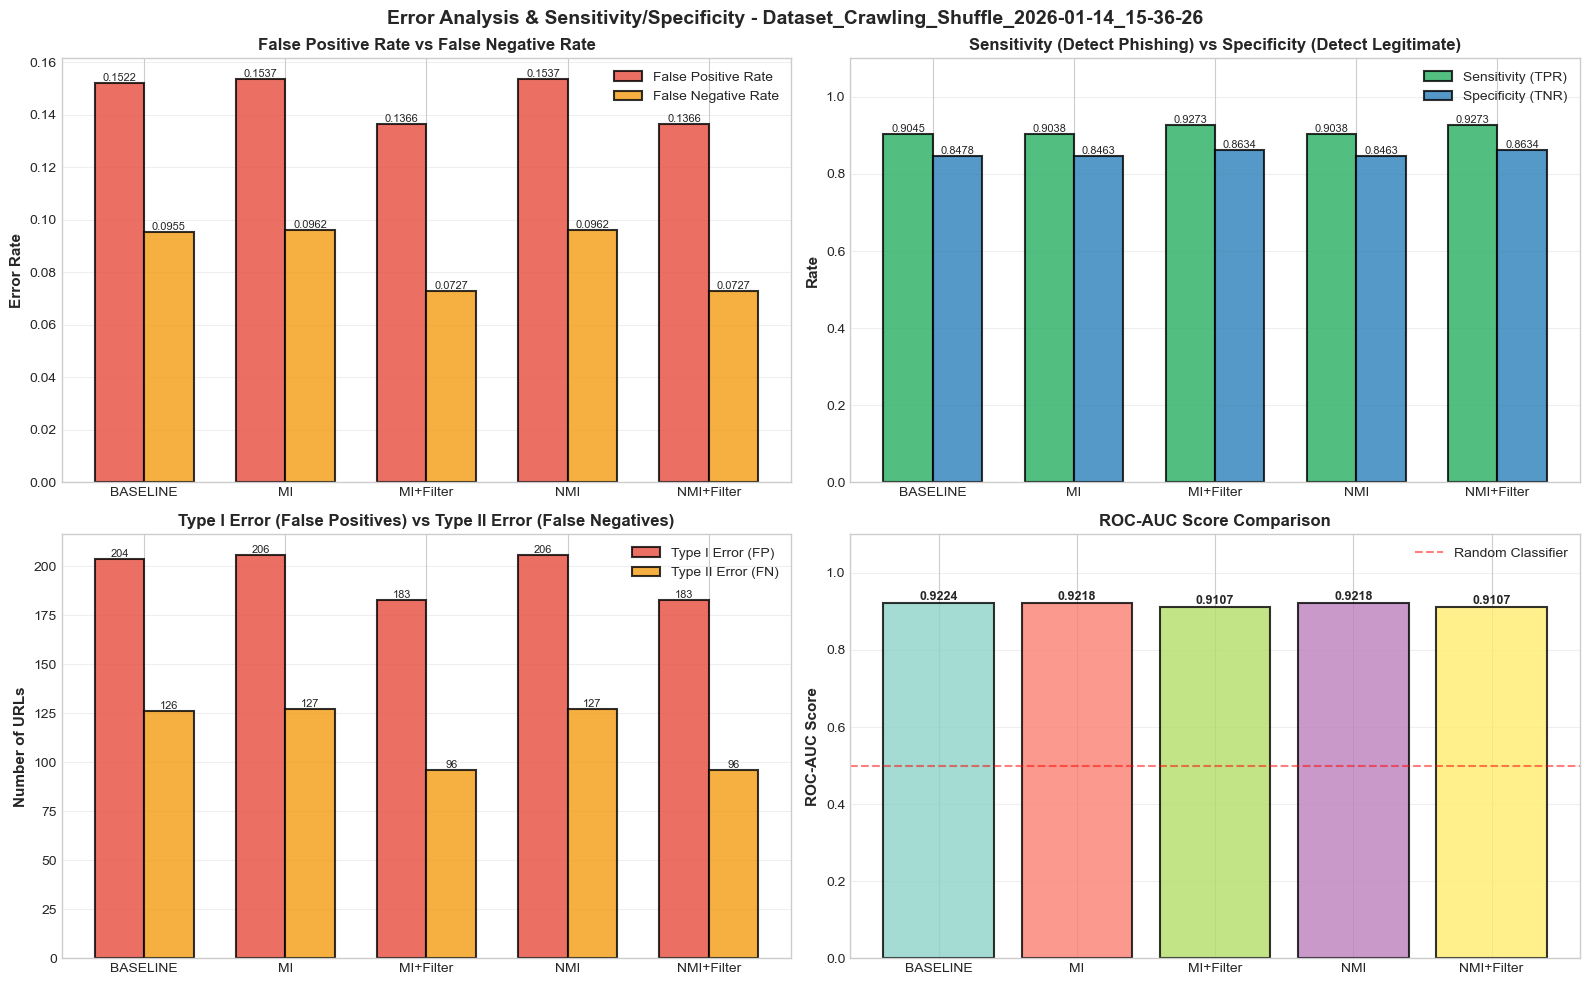

✓ Saved: 05_error_analysis_Gabung.png


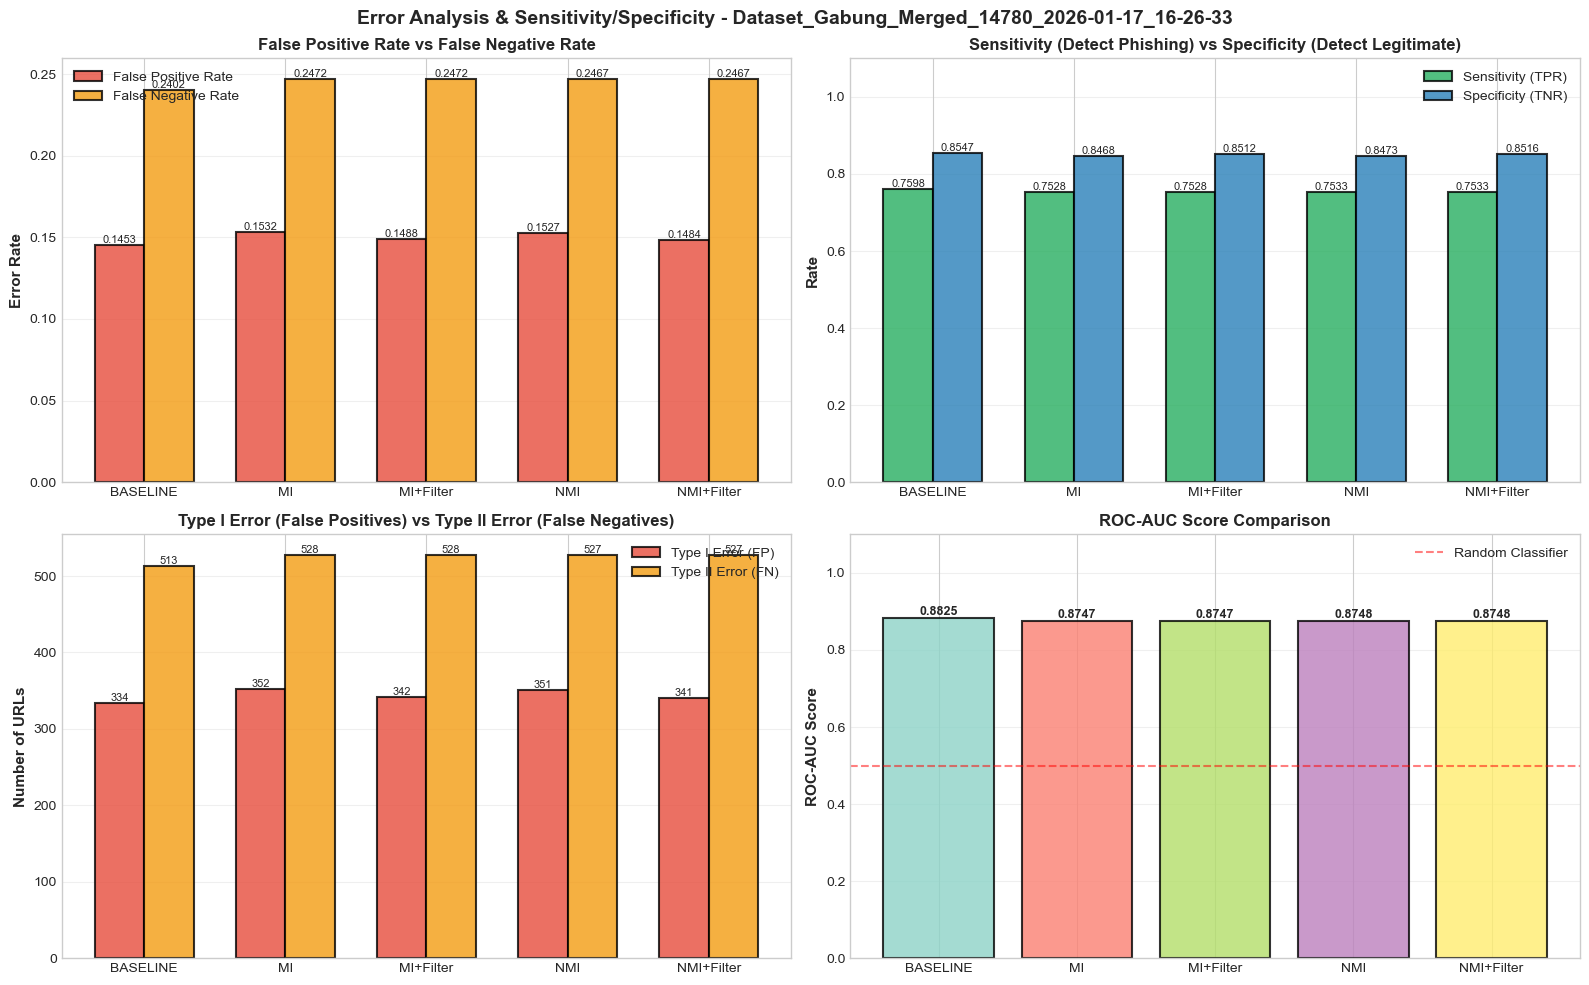

✓ Saved: 06_feature_efficiency.png


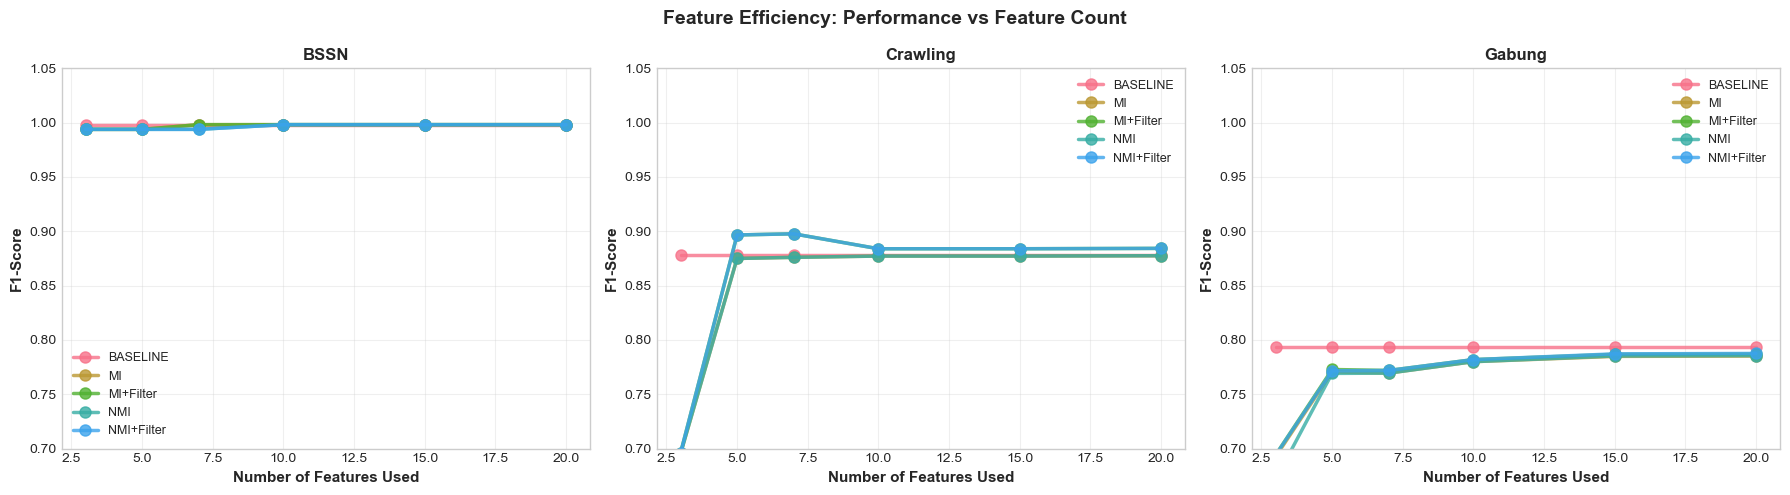

✓ Saved: 07_cross_dataset_model_comparison.png


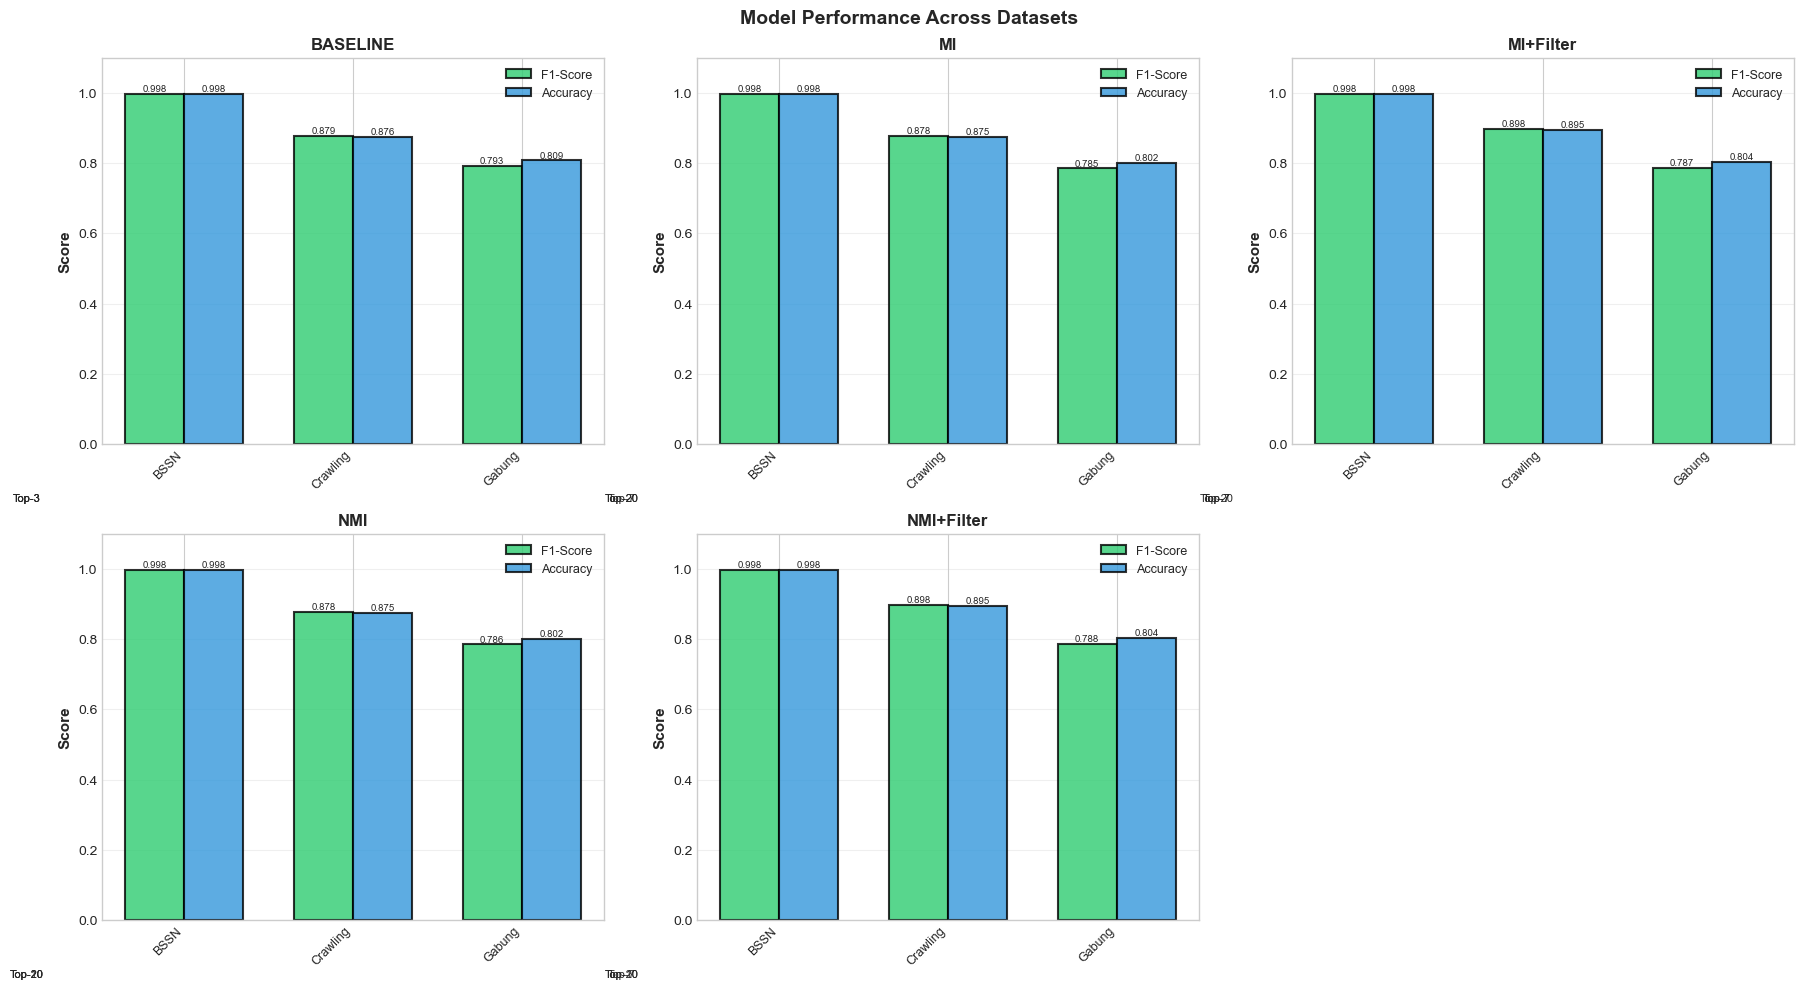

✓ Saved: 08_confusion_matrix_best_models.png


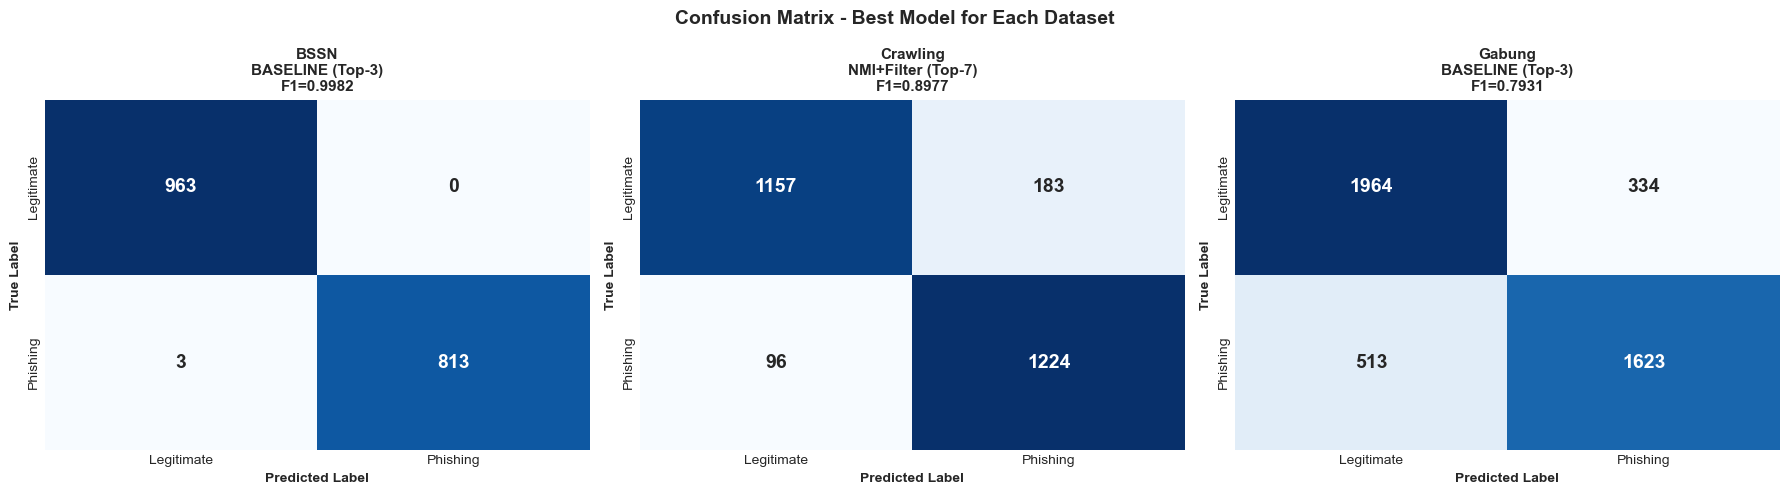

✓ Saved: 09_summary_best_models_table.png


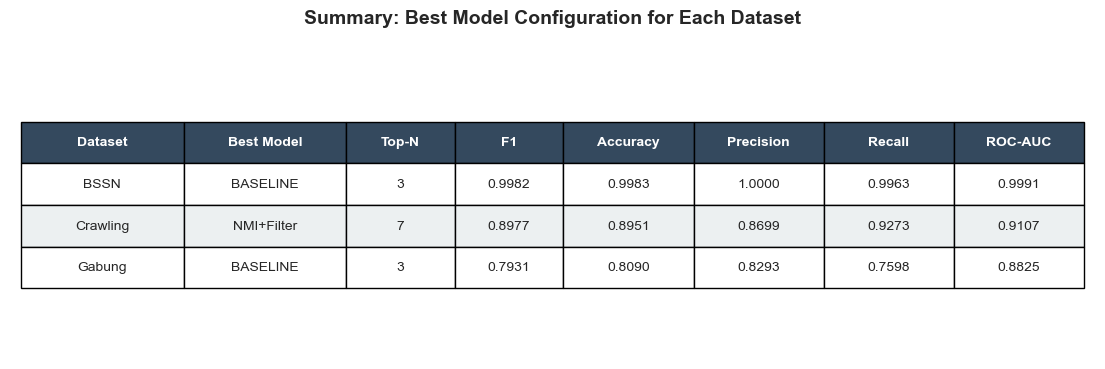


ALL ADVANCED VISUALIZATIONS GENERATED SUCCESSFULLY!

Total visualizations saved: 8 files

Files created:
  1. 01_metrics_comparison_all_models.png
  2. 02_f1_heatmap_all_models.png
  3. 03_topn_comparison_*.png (for each dataset)
  4. 04_model_comparison_*.png (for each dataset)
  5. 05_error_analysis_*.png (for each dataset)
  6. 06_feature_efficiency.png
  7. 07_cross_dataset_model_comparison.png
  8. 08_confusion_matrix_best_models.png
  9. 09_summary_best_models_table.png


In [17]:
"""
ADVANCED VISUALIZATION: ERROR ANALYSIS, SENSITIVITY/SPECIFICITY & EFFICIENCY
"""

print("\n" + "=" * 150)
print("GENERATING ADVANCED VISUALIZATIONS")
print("=" * 150)

# ============================================================================
# 1. ERROR ANALYSIS - FALSE POSITIVE RATE vs FALSE NEGATIVE RATE
# ============================================================================

for dataset in sorted(final_results['Dataset'].unique()):
    dataset_data = final_results[final_results['Dataset'] == dataset]
    best_results_dataset = dataset_data.loc[dataset_data.groupby('Model')['F1'].idxmax()]
    
    # Calculate error metrics
    error_data = []
    for _, row in best_results_dataset.iterrows():
        tn, fp, fn, tp = int(row['TN']), int(row['FP']), int(row['FN']), int(row['TP'])
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        error_data.append({
            'Model': row['Model'],
            'FPR': fpr,
            'FNR': fnr,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'Type_I': fp,
            'Type_II': fn
        })
    
    error_df = pd.DataFrame(error_data)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Error Analysis & Sensitivity/Specificity - {dataset}', 
                fontsize=14, fontweight='bold')
    
    models = error_df['Model'].values
    x = np.arange(len(models))
    width = 0.35
    colors = plt.cm.Set3(np.linspace(0, 1, len(models)))
    
    # 1. FPR vs FNR
    ax = axes[0, 0]
    bars1 = ax.bar(x - width/2, error_df['FPR'], width, label='False Positive Rate', 
                  color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, error_df['FNR'], width, label='False Negative Rate', 
                  color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Error Rate', fontsize=11, fontweight='bold')
    ax.set_title('False Positive Rate vs False Negative Rate', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}', ha='center', va='bottom', fontsize=8)
    
    # 2. Sensitivity vs Specificity
    ax = axes[0, 1]
    bars1 = ax.bar(x - width/2, error_df['Sensitivity'], width, label='Sensitivity (TPR)', 
                  color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, error_df['Specificity'], width, label='Specificity (TNR)', 
                  color='#2980b9', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Rate', fontsize=11, fontweight='bold')
    ax.set_title('Sensitivity (Detect Phishing) vs Specificity (Detect Legitimate)', 
                fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.1])
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}', ha='center', va='bottom', fontsize=8)
    
    # 3. Type I & Type II Errors (Count)
    ax = axes[1, 0]
    bars1 = ax.bar(x - width/2, error_df['Type_I'], width, label='Type I Error (FP)', 
                  color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, error_df['Type_II'], width, label='Type II Error (FN)', 
                  color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Number of URLs', fontsize=11, fontweight='bold')
    ax.set_title('Type I Error (False Positives) vs Type II Error (False Negatives)', 
                fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height):,}', ha='center', va='bottom', fontsize=8)
    
    # 4. ROC-AUC comparison
    ax = axes[1, 1]
    roc_auc_scores = best_results_dataset['ROC_AUC'].values
    bars = ax.bar(models, roc_auc_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
    ax.set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Classifier')
    ax.legend(fontsize=10)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    dataset_name_short = dataset.split('_')[1] if '_' in dataset else dataset[:15]
    plt.savefig(f'{output_folder}/05_error_analysis_{dataset_name_short}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: 05_error_analysis_{dataset_name_short}.png")
    plt.show()

# ============================================================================
# 2. FEATURE EFFICIENCY - PERFORMANCE vs NUMBER OF FEATURES
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Efficiency: Performance vs Feature Count', fontsize=14, fontweight='bold')

datasets_list = sorted(final_results['Dataset'].unique())
models_list = sorted(final_results['Model'].unique())

for idx, dataset in enumerate(datasets_list):
    ax = axes[idx]
    dataset_data = final_results[final_results['Dataset'] == dataset]
    
    for model in models_list:
        model_data = dataset_data[dataset_data['Model'] == model].sort_values('Top_N')
        
        ax.plot(model_data['Top_N'].astype(int), model_data['F1'], 
               marker='o', linewidth=2.5, markersize=8, label=model, alpha=0.8)
    
    ax.set_title(f'{dataset.split("_")[1] if "_" in dataset else dataset[:15]}', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Features Used', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim([0.7, 1.05])
    
plt.tight_layout()
plt.savefig(f'{output_folder}/06_feature_efficiency.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 06_feature_efficiency.png")
plt.show()

# ============================================================================
# 3. CROSS-DATASET COMPARISON FOR EACH MODEL
# ============================================================================

best_results_by_model_dataset = final_results.loc[final_results.groupby(['Dataset', 'Model'])['F1'].idxmax()]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Across Datasets', fontsize=14, fontweight='bold')

for idx, model in enumerate(sorted(models_list)):
    ax = axes[idx // 3, idx % 3]
    
    model_results = best_results_by_model_dataset[best_results_by_model_dataset['Model'] == model]
    
    if len(model_results) > 0:
        datasets = model_results['Dataset'].values
        f1_scores = model_results['F1'].values
        accuracy = model_results['Accuracy'].values
        top_ns = model_results['Top_N'].values
        
        x = np.arange(len(datasets))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', 
                      color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x + width/2, accuracy, width, label='Accuracy', 
                      color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
        
        ax.set_title(f'{model}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Score', fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([d.split('_')[1] if '_' in d else d[:10] for d in datasets], 
                          fontsize=9, rotation=45, ha='right')
        ax.legend(fontsize=9)
        ax.set_ylim([0, 1.1])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add Top-N info
        for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
            ax.text(-0.15, -0.15, f'Top-{int(top_ns[i])}', 
                   transform=ax.transAxes, fontsize=8, ha='center')
        
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=7)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])

# Hide the extra subplot if needed
if len(models_list) < 6:
    axes[1, 2].set_visible(False)

plt.tight_layout()
plt.savefig(f'{output_folder}/07_cross_dataset_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 07_cross_dataset_model_comparison.png")
plt.show()

# ============================================================================
# 4. CONFUSION MATRIX SUMMARY (Best Model for Each Dataset)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix - Best Model for Each Dataset', fontsize=14, fontweight='bold')

for idx, dataset in enumerate(sorted(datasets_list)):
    dataset_data = final_results[final_results['Dataset'] == dataset]
    best_model = dataset_data.loc[dataset_data['F1'].idxmax()]
    
    tn, fp, fn, tp = int(best_model['TN']), int(best_model['FP']), int(best_model['FN']), int(best_model['TP'])
    
    cm = np.array([[tn, fp], [fn, tp]])
    
    ax = axes[idx]
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
               xticklabels=['Legitimate', 'Phishing'],
               yticklabels=['Legitimate', 'Phishing'],
               annot_kws={'size': 14, 'weight': 'bold'})
    
    dataset_short = dataset.split('_')[1] if '_' in dataset else dataset[:15]
    ax.set_title(f'{dataset_short}\n{best_model["Model"]} (Top-{int(best_model["Top_N"])})\nF1={best_model["F1"]:.4f}',
                fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_folder}/08_confusion_matrix_best_models.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 08_confusion_matrix_best_models.png")
plt.show()

# ============================================================================
# 5. SUMMARY TABLE - BEST MODEL FOR EACH DATASET
# ============================================================================

summary_data = []
for dataset in sorted(datasets_list):
    dataset_data = final_results[final_results['Dataset'] == dataset]
    best_model = dataset_data.loc[dataset_data['F1'].idxmax()]
    
    summary_data.append({
        'Dataset': dataset.split('_')[1] if '_' in dataset else dataset[:15],
        'Best Model': best_model['Model'],
        'Top-N': int(best_model['Top_N']),
        'F1': f"{best_model['F1']:.4f}",
        'Accuracy': f"{best_model['Accuracy']:.4f}",
        'Precision': f"{best_model['Precision']:.4f}",
        'Recall': f"{best_model['Recall']:.4f}",
        'ROC-AUC': f"{best_model['ROC_AUC']:.4f}"
    })

summary_table = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_table.values, colLabels=summary_table.columns,
                cellLoc='center', loc='center', colWidths=[0.15, 0.15, 0.1, 0.1, 0.12, 0.12, 0.12, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(len(summary_table.columns)):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_table) + 1):
    for j in range(len(summary_table.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.title('Summary: Best Model Configuration for Each Dataset', 
         fontsize=14, fontweight='bold', pad=20)
plt.savefig(f'{output_folder}/09_summary_best_models_table.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 09_summary_best_models_table.png")
plt.show()

print("\n" + "=" * 150)
print("ALL ADVANCED VISUALIZATIONS GENERATED SUCCESSFULLY!")
print("=" * 150)
print(f"\nTotal visualizations saved: 8 files")
print("\nFiles created:")
print("  1. 01_metrics_comparison_all_models.png")
print("  2. 02_f1_heatmap_all_models.png")
print("  3. 03_topn_comparison_*.png (for each dataset)")
print("  4. 04_model_comparison_*.png (for each dataset)")
print("  5. 05_error_analysis_*.png (for each dataset)")
print("  6. 06_feature_efficiency.png")
print("  7. 07_cross_dataset_model_comparison.png")
print("  8. 08_confusion_matrix_best_models.png")
print("  9. 09_summary_best_models_table.png")
